## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB, ComplementNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import StratifiedKFold
import json



## Load Dataset

In [2]:
df = pd.read_csv("Fifa.csv")
df.head()

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,Agostinho Mabululu,Angola,LW,30,68,68,Ittihad Alexandria,0.65,1660
1,Mahmoud Gennesh,Egypt,GK,35,67,67,Ittihad Alexandria,0.35,1620
2,Sobhi Suleiman,Egypt,GK,28,63,65,Ittihad Alexandria,0.20,1480
3,Mahmoud Alaa,Egypt,CB,32,68,68,Ittihad Alexandria,0.50,1695
4,Mahmoud Shabana,Egypt,CB,30,66,66,Ittihad Alexandria,0.40,1640


##  Exploratory Data Analysis (EDA)

In [3]:
print(df.shape)
df.info()

(19667, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19667 entries, 0 to 19666
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Name               19667 non-null  object 
 1   Country            19667 non-null  object 
 2   Position           19667 non-null  object 
 3   Age                19667 non-null  int64  
 4   Overall_Rating     19667 non-null  int64  
 5   Future Potential   19667 non-null  int64  
 6   Team               19667 non-null  object 
 7   Value Per M$       19667 non-null  float64
 8   Total_Stats Score  19667 non-null  int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 1.4+ MB


### Missing Values
The dataset was checked for missing values.

- No Missing values are found 

In [4]:
df.isnull()

,Name,Country,Position,Age,Overall_Rating,Future Potential,Team,Value Per M$,Total_Stats Score
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
19662,False,False,False,False,False,False,False,False,False
19663,False,False,False,False,False,False,False,False,False
19664,False,False,False,False,False,False,False,False,False
19665,False,False,False,False,False,False,False,False,False


In [5]:
print(df.isnull().sum())

Name                 0
Country              0
Position             0
Age                  0
Overall_Rating       0
Future Potential     0
Team                 0
Value Per M$         0
Total_Stats Score    0
dtype: int64


# No missing values found

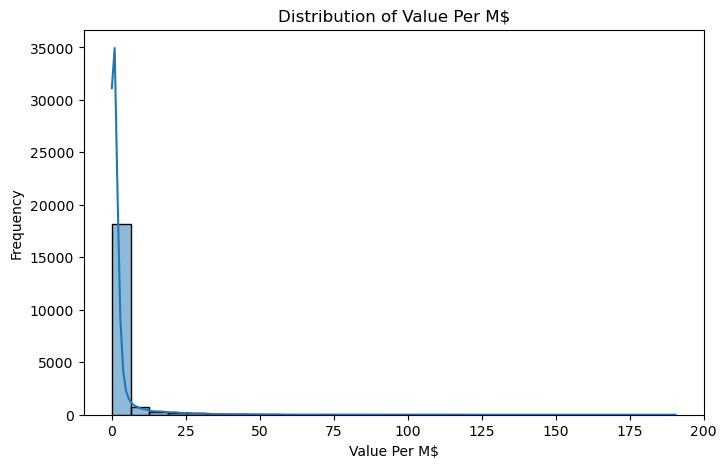

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df["Value Per M$"], bins=30, kde=True)
plt.title("Distribution of Value Per M$")
plt.xlabel("Value Per M$")
plt.ylabel("Frequency")
plt.show()

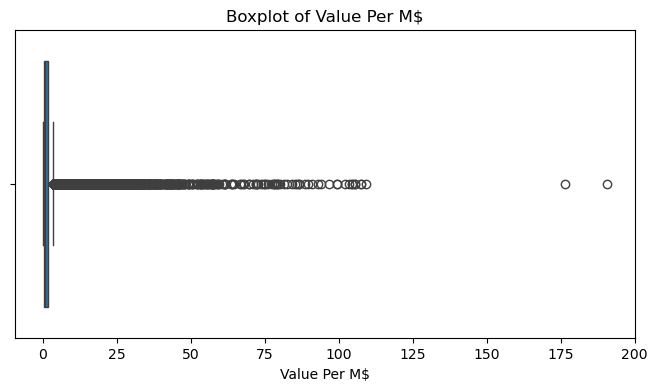

In [7]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df["Value Per M$"])
plt.title("Boxplot of Value Per M$")
plt.show()

In [8]:
skew_value = df["Value Per M$"].skew()
print("Skewness:", skew_value)

Skewness: 7.983215201865151


### Since the skewness is much greater than 0,  then it is Right-skewed  the distribution is highly positively skewed rather than normal. This indicates the presence of extreme high-value outliers.


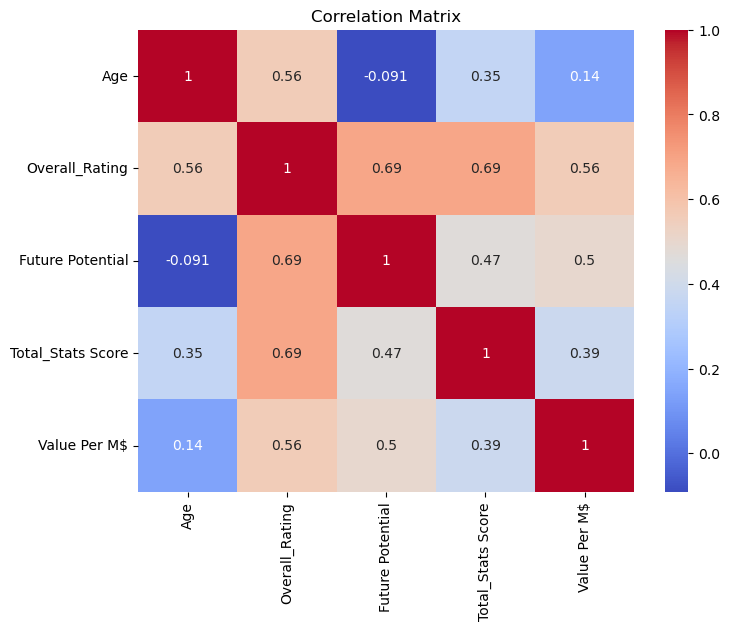

In [9]:
numeric_cols = ["Age", "Overall_Rating", "Future Potential", "Total_Stats Score", "Value Per M$"]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [10]:
print(corr["Value Per M$"].sort_values(ascending=False))

Value Per M$         1.000000
Overall_Rating       0.560648
Future Potential     0.500964
Total_Stats Score    0.385062
Age                  0.142276
Name: Value Per M$, dtype: float64


##### Overall_Rating has the strongest positive relationship with player value.  Future Potential is also strongly related, meaning players with higher future potential tend to have higher market value. Total_Stats Score has a moderate positive relationship. Age has only a weak relationship. Conclusion: The most influential numerical features related to Value Per M$ appear to be Overall_Rating and Future Potential. indicating that higher-rated and more promising players tend to have greater market values.

In [11]:
avg_rating = df.groupby("Position")["Overall_Rating"].mean().sort_values(ascending=False)
print(avg_rating)

Position
SW     75.000000
RF     75.000000
CF     66.042857
LW     64.345979
CDM    64.234168
LM     64.172009
RWB    64.063973
LWB    64.043333
RM     63.907731
RW     63.718529
CAM    63.679709
CB     63.544448
LB     63.276794
ST     63.087505
RB     62.863636
CM     62.511767
GK     60.987288
Name: Overall_Rating, dtype: float64


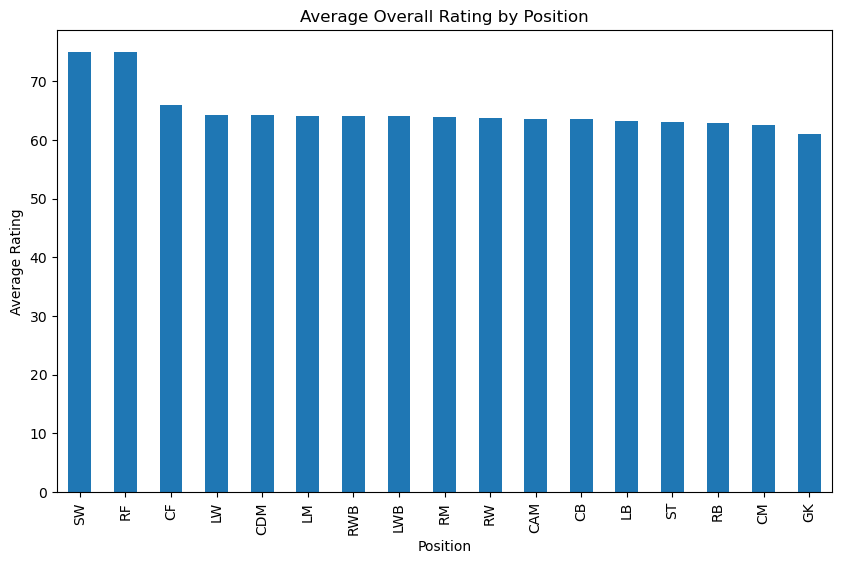

In [12]:
plt.figure(figsize=(10,6))
avg_rating.plot(kind='bar')
plt.title("Average Overall Rating by Position")
plt.xlabel("Position")
plt.ylabel("Average Rating")
plt.show()

#### Top positions by average rating: SW: 75.00   RF: 75.00  CF: 66.04  LW: 64.35  CDM: 64.23   Lower average ratings: CM: 62.51  GK: 60.99   Conclusion: Forward and specialized positions tend to have higher average ratings, while goalkeepers have the lowest average rating in this dataset.

# Data Preprocessing 

# train/test split

In [13]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    df,
    test_size=0.2,
   random_state=1
)

print("Train:", train.shape)
print("Test:", test.shape)

Train: (15733, 9)
Test: (3934, 9)


In [14]:
x_train=train
x_test= test

# y = target
y_train_value = train["Value Per M$"]
y_test_value = test["Value Per M$"]

y_train_rating = train["Overall_Rating"]
y_test_rating = test["Overall_Rating"]

 

In [15]:
num_cols = x_train.select_dtypes(include='number').columns.tolist()
cat_cols = x_train.select_dtypes(include=['object','string']).columns.tolist()

print("Numerical:", num_cols)
print("Categorical:", cat_cols)

Numerical: ['Age', 'Overall_Rating', 'Future Potential', 'Value Per M$', 'Total_Stats Score']
Categorical: ['Name', 'Country', 'Position', 'Team']


This separation is required because numerical and categorical data need different preprocessing methods.


# outliers

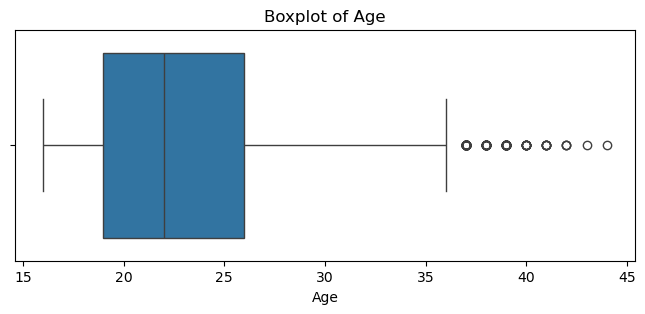

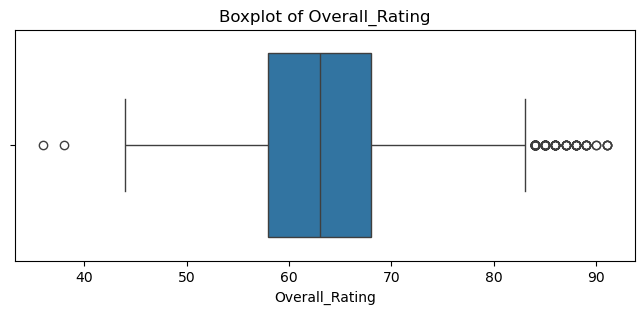

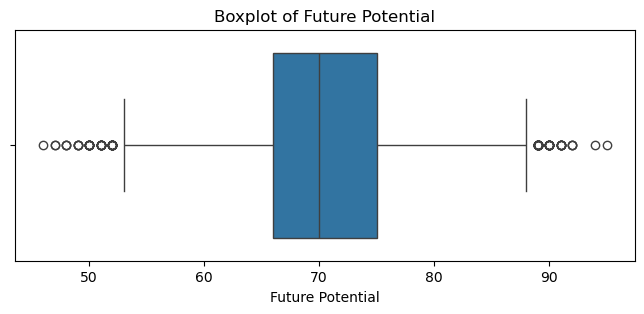

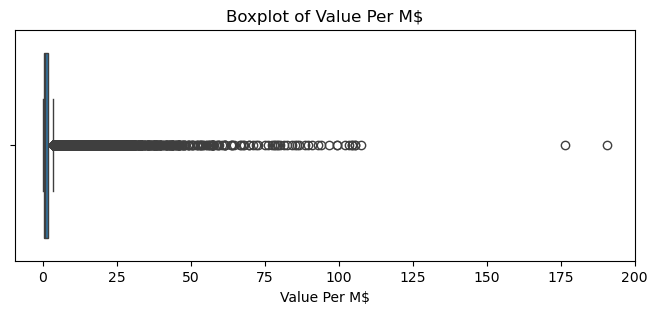

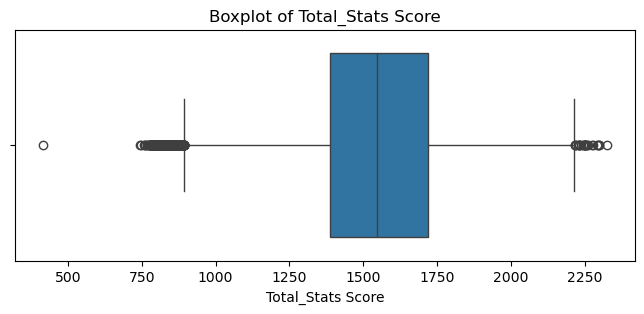

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:
    plt.figure(figsize=(8,3))
    sns.boxplot(x=x_train[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [17]:
for col in num_cols:
    Q1 = x_train[col].quantile(0.25)
    Q3 = x_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = x_train[(x_train[col] < lower) | (x_train[col] > upper)]

    print(col, ":", len(outliers), "outliers")

Age : 135 outliers
Overall_Rating : 122 outliers
Future Potential : 99 outliers
Value Per M$ : 1935 outliers
Total_Stats Score : 676 outliers


In [18]:
print(x_train["Age"].describe())

count    15733.000000
mean        22.992500
std          4.685284
min         16.000000
25%         19.000000
50%         22.000000
75%         26.000000
max         44.000000
Name: Age, dtype: float64


In [19]:
print(x_train["Future Potential"].describe())

count    15733.000000
mean        70.666497
std          6.488852
min         46.000000
25%         66.000000
50%         70.000000
75%         75.000000
max         95.000000
Name: Future Potential, dtype: float64


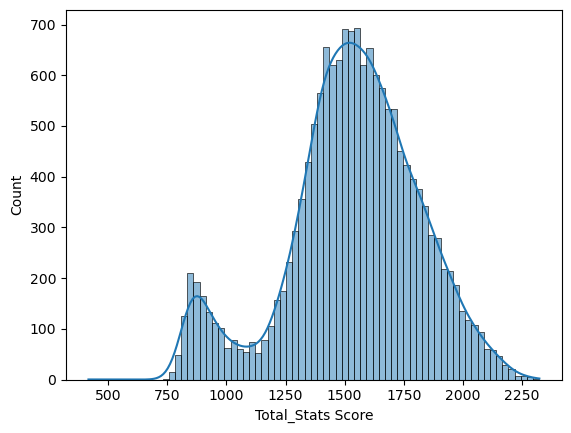

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(x_train["Total_Stats Score"], kde=True)
plt.show()

In [21]:
x_train["Total_Stats Score"].describe()

count    15733.000000
mean      1534.277252
std        283.455747
min        416.000000
25%       1389.000000
50%       1548.000000
75%       1719.000000
max       2324.000000
Name: Total_Stats Score, dtype: float64

In [22]:
train_clean = train.copy()

cols = ["Age", "Future Potential", "Total_Stats Score"]
train_clean = train.copy()

cols = ["Age", "Future Potential", "Total_Stats Score"]

for col in cols:
    Q1 = train_clean[col].quantile(0.25)
    Q3 = train_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

#    train_clean = train_clean[
#        (train_clean[col] >= lower) &
#        (train_clean[col] <= upper)
#    ]
 

# HANDLING OUTLIERS 

In [23]:
for col in cols:
    Q1 = train_clean[col].quantile(0.25)
    Q3 = train_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = train_clean[
        (train_clean[col] < lower) |
        (train_clean[col] > upper)
    ]

    print(col, ":", len(outliers), "outliers")

Age : 135 outliers
Future Potential : 99 outliers
Total_Stats Score : 676 outliers


In [24]:
cols = ["Age","Future Potential", "Total_Stats Score"]

for col in cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    train[col] = train[col].clip(lower, upper)
    test[col] = test[col].clip(lower, upper)

In [25]:
for col in cols:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = train[
        (train[col] < lower) |
        (train[col] > upper)
    ]

    print(col, ":", len(outliers), "outliers")

Age : 0 outliers
Future Potential : 0 outliers
Total_Stats Score : 0 outliers


Total_Stats Score : 0 outliers


In [26]:
cat_cols = ["Country", "Position", "Team"]

In [27]:
x_train_model = x_train[num_cols + cat_cols].copy()
x_test_model = x_test[num_cols + cat_cols].copy()

### 6. Encoding Categorical Features

Machine learning models require numerical input, so categorical columns were converted into numeric format using One-Hot Encoding with get_dummies().

The following categorical columns were encoded:

- Name  
- Country  
- Position  
- Team

In [28]:
x_train_model = pd.get_dummies(
    x_train_model,
    columns=cat_cols,
    drop_first=True
)

x_test_model = pd.get_dummies(
    x_test_model,
    columns=cat_cols,
    drop_first=True
)

In [29]:
x_train_model, x_test_model = x_train_model.align(
    x_test_model,
    join='left',
    axis=1,
    fill_value=0
)

In [30]:
#unscaled features
x_train_rating_unscaled=x_train_model.drop(columns=["Overall_Rating"]).copy()
x_test_rating_unscaled=x_test_model.drop(columns=["Overall_Rating"]).copy()
x_test_rating_unscaled

,Age,Future Potential,Value Per M$,Total_Stats Score,Country_Algeria,Country_Angola,Country_Argentina,Country_Armenia,Country_Australia,Country_Austria,...,Team_Zwickau,Team_Zürich,Team_Ñublense,Team_Örebro,Team_Östersunds FK,Team_Ümraniyespor,Team_İstanbul Başakşehir,Team_İstanbulspor,Team_ŁKS Łódź,Team_Śląsk Wrocław
9601,27.0,69.0,1.400,1881,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9225,19.0,73.0,0.975,1511,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11165,20.0,75.0,1.600,1668,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
15641,24.0,64.0,0.350,1421,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
16565,20.0,69.0,0.475,1540,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3248,23.0,74.0,1.900,1616,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
16244,23.0,76.0,2.500,1846,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11832,18.0,63.0,0.140,1374,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
15649,24.0,71.0,1.200,1686,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### 8. Feature Scaling

Numerical features were standardized using *StandardScaler*.
The scaler was fitted only on the training data, then applied to both training and testing sets.
Scaled numerical columns: Age  Overall_Rating Future Potential Value Per M$ Total_Stats Score  
Standardization transforms data to:
- Mean ≈ 0  
- Standard Deviation ≈ 1
This helps models perform better, especially distance-based and gradient-based algorithms.

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_model[num_cols] = scaler.fit_transform(x_train_model[num_cols])
x_test_model[num_cols] = scaler.transform(x_test_model[num_cols])

In [32]:
x_train_model
x_test_model

,Age,Overall_Rating,Future Potential,Value Per M$,Total_Stats Score,Country_Algeria,Country_Angola,Country_Argentina,Country_Armenia,Country_Australia,...,Team_Zwickau,Team_Zürich,Team_Ñublense,Team_Örebro,Team_Östersunds FK,Team_Ümraniyespor,Team_İstanbul Başakşehir,Team_İstanbulspor,Team_ŁKS Łódź,Team_Śląsk Wrocław
9601,0.867882,0.607574,-0.258268,-0.154874,1.237582,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
9225,-0.857968,-0.030890,0.361201,-0.212503,-0.090171,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
11165,-0.642237,0.224495,0.670935,-0.127754,0.473227,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
15641,0.220688,-0.413969,-1.032603,-0.297253,-0.413138,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
16565,-0.642237,-0.541662,-0.258268,-0.280303,0.013896,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3248,0.004957,0.735267,0.516068,-0.087074,0.286624,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
16244,0.004957,0.862960,0.825802,-0.005715,1.111984,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
11832,-1.073699,-1.563205,-1.187470,-0.325728,-0.581799,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
15649,0.220688,0.352188,0.051467,-0.181994,0.537820,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [33]:
x_train_value = x_train_model.drop(columns=["Value Per M$"])
x_test_value = x_test_model.drop(columns=["Value Per M$"]) 
x_train_value 

,Age,Overall_Rating,Future Potential,Total_Stats Score,Country_Algeria,Country_Angola,Country_Argentina,Country_Armenia,Country_Australia,Country_Austria,...,Team_Zwickau,Team_Zürich,Team_Ñublense,Team_Örebro,Team_Östersunds FK,Team_Ümraniyespor,Team_İstanbul Başakşehir,Team_İstanbulspor,Team_ŁKS Łódź,Team_Śląsk Wrocław
15046,0.867882,0.862960,0.206334,0.017485,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
15914,-0.210774,-0.413969,-0.258268,-0.079405,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
18918,-0.426506,-0.158583,-0.103401,-0.434669,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
18080,0.004957,-0.669355,-0.877736,-2.304289,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
951,-0.426506,0.990652,2.219606,0.573706,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10955,-1.073699,-0.797048,-0.258268,-0.922708,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
17289,-0.210774,0.352188,0.361201,0.254327,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5192,1.083613,0.224495,-0.877736,-2.024384,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
12172,-0.642237,-1.435512,-1.342337,-0.388018,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [34]:
x_train_rating = x_train_model.drop(columns=["Overall_Rating"])
x_test_rating = x_test_model.drop(columns=["Overall_Rating"])
x_train_rating

,Age,Future Potential,Value Per M$,Total_Stats Score,Country_Algeria,Country_Angola,Country_Argentina,Country_Armenia,Country_Australia,Country_Austria,...,Team_Zwickau,Team_Zürich,Team_Ñublense,Team_Örebro,Team_Östersunds FK,Team_Ümraniyespor,Team_İstanbul Başakşehir,Team_İstanbulspor,Team_ŁKS Łódź,Team_Śląsk Wrocław
15046,0.867882,0.206334,-0.114194,0.017485,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
15914,-0.210774,-0.258268,-0.270133,-0.079405,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
18918,-0.426506,-0.103401,-0.222673,-0.434669,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
18080,0.004957,-0.877736,-0.297253,-2.304289,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
951,-0.426506,2.219606,0.279043,0.573706,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10955,-1.073699,-0.258268,-0.297253,-0.922708,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
17289,-0.210774,0.361201,-0.100634,0.254327,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5192,1.083613,-0.877736,-0.276913,-2.024384,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
12172,-0.642237,-1.342337,-0.321660,-0.388018,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


# task 3

To perform classification, players were grouped into *4 performance tiers* based on their *Overall_Rating*.

The target classes created were:

- Low  
- Mid  
- High  
- Elite

In [35]:
print(train["Overall_Rating"].describe())

count    15733.000000
mean        63.241912
std          7.831541
min         36.000000
25%         58.000000
50%         63.000000
75%         68.000000
max         91.000000
Name: Overall_Rating, dtype: float64


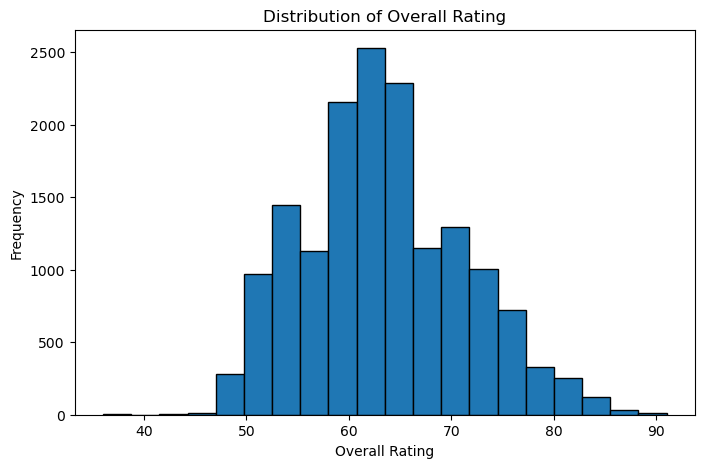

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(train["Overall_Rating"], bins=20, edgecolor="black")
plt.title("Distribution of Overall Rating")
plt.xlabel("Overall Rating")
plt.ylabel("Frequency")
plt.show()

Summary statistics for *Overall_Rating*:

- *Minimum:* 36  
- *25th Percentile:* 58  
- *Median:* 63  
- *75th Percentile:* 68  
- *Maximum:* 91  
- *Mean:* 63.24  
- *Standard Deviation:* 7.83  

A histogram of the ratings was plotted to visualize the distribution. The ratings were concentrated around the low-to-mid 60s, with fewer players having very high ratings.


In [37]:
#print(train["Overall_Rating"].quantile([0.25, 0.50, 0.75]))

In [38]:
rating_train = train["Overall_Rating"]
rating_test = test["Overall_Rating"]

q1 = rating_train.quantile(0.30)
q2 = rating_train.quantile(0.60)
q3 = rating_train.quantile(0.90)

print(q1)
print(q2)
print(q3)

59.0
65.0
74.0


In [39]:
def category(rating):
    if rating <= q1:
        return "Low"
    elif rating <= q2:
        return "Mid"
    elif rating <= q3:
        return "High"
    else:
        return "Elite"

Choosing Thresholds for Categories

Thresholds were selected using *training-set percentiles* to create meaningful performance groups while reducing severe class imbalance.

Selected percentile cutoffs:

- *30th Percentile = 59*
- *60th Percentile = 65*
- *90th Percentile = 74*

Based on these values, players were categorized as:

- *Low:* Rating ≤ 59  
- *Mid:* 59 < Rating ≤ 65  
- *High:* 65 < Rating ≤ 74  
- *Elite:* Rating > 74  


In [40]:
y_train_tier = rating_train.apply(category)
y_test_tier = rating_test.apply(category)

y_train_tier.name = "Performance Tier"
y_test_tier.name = "Performance Tier"

In [41]:
print(y_train_tier.value_counts())
print()
print(y_test_tier.value_counts())

Performance Tier
Low      5137
Mid      4995
High     4130
Elite    1471
Name: count, dtype: int64

Performance Tier
Low      1280
Mid      1261
High     1061
Elite     332
Name: count, dtype: int64


### Class Distribution After Splitting

#### Training Set

- *Low:* 5137  
- *Mid:* 4995  
- *High:* 4130  
- *Elite:* 1471  

#### Test Set

- *Low:* 1280  
- *Mid:* 1261  
- *High:* 1061  
- *Elite:* 332

###  Justification of Thresholds

Percentiles were used instead of equal-width ranges because ratings are not uniformly distributed.

This approach was chosen because:

- It reflects the actual spread of player ratings.
- It creates more realistic performance groups.
- It reduces extreme imbalance compared to arbitrary fixed ranges.
- It reserves the *Elite* category for top-performing players only.

Using the 90th percentile for Elite means only the top ~10% of players are labeled elite, which matches real-world expectations.


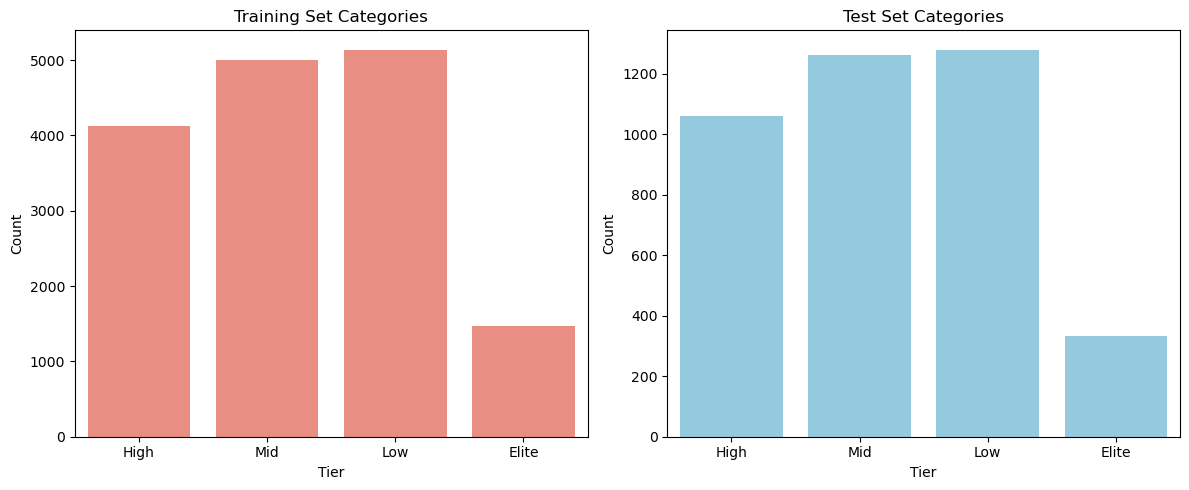

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.countplot(ax=axes[0], x=y_train_tier, color="salmon")
axes[0].set_title("Training Set Categories")
axes[0].set_xlabel("Tier")
axes[0].set_ylabel("Count")

sns.countplot(ax=axes[1], x=y_test_tier, color="skyblue")
axes[1].set_title("Test Set Categories")
axes[1].set_xlabel("Tier")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

### Class Distribution Visualization

Bar charts were created for both training and testing sets to compare category frequencies.

The plots show that:

- Low, Mid, and High classes are relatively close in size.
- Elite has noticeably fewer samples.



###  Is the Dataset Balanced?

The dataset is *moderately imbalanced*.

- The first three classes are reasonably balanced.
- The *Elite* class is smaller than the others.

However, the imbalance is not severe enough to prevent classification, and models such as Logistic Regression and Naïve Bayes can still perform effectively.


## Naive Bayes models

### - GaussianNB model

####   --scaled features

 GaussianNB Accuracy: 0.8172
              precision    recall  f1-score   support

       Elite       0.86      0.80      0.83       332
        High       0.83      0.71      0.77      1061
         Low       0.91      0.89      0.90      1280
         Mid       0.72      0.84      0.78      1261

    accuracy                           0.82      3934
   macro avg       0.83      0.81      0.82      3934
weighted avg       0.82      0.82      0.82      3934



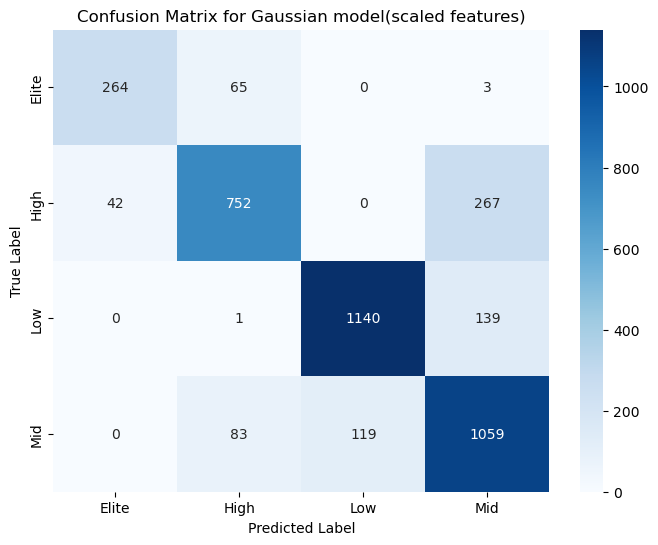

In [43]:
no_features=['Age','Future Potential', 'Value Per M$', 'Total_Stats Score']

x_train_gaussian=x_train_rating[no_features]
x_test_gaussian=x_test_rating[no_features]

NB_model1= GaussianNB()
NB_model1=NB_model1.fit(x_train_gaussian, y_train_tier)
y_pred_tier = NB_model1.predict(x_test_gaussian)
print(f" GaussianNB Accuracy: {accuracy_score(y_test_tier, y_pred_tier):.4f}")
print(classification_report(y_test_tier, y_pred_tier))
class_names1=NB_model1.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_tier, y_pred_tier), annot=True, fmt='d', cmap='Blues',xticklabels=class_names1,yticklabels=class_names1)
plt.title('Confusion Matrix for Gaussian model(scaled features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#### --unscaled features

 GaussianNB Accuracy: 0.8172
              precision    recall  f1-score   support

       Elite       0.86      0.80      0.83       332
        High       0.83      0.71      0.77      1061
         Low       0.91      0.89      0.90      1280
         Mid       0.72      0.84      0.78      1261

    accuracy                           0.82      3934
   macro avg       0.83      0.81      0.82      3934
weighted avg       0.82      0.82      0.82      3934



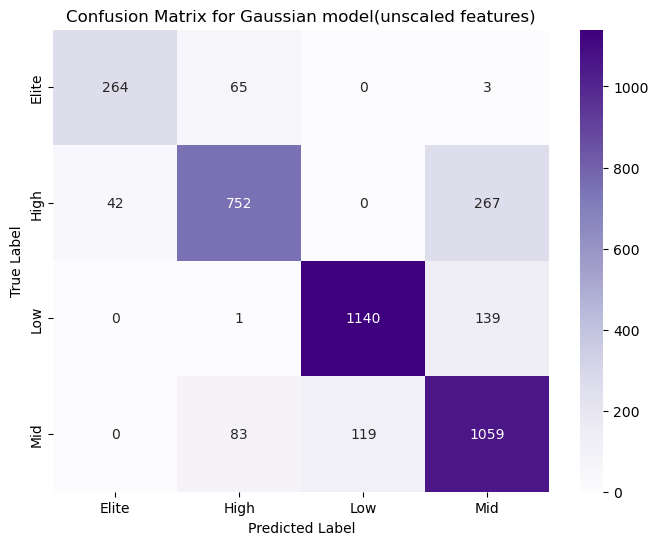

In [44]:
x_train_gaussian_unscaled=x_train_rating_unscaled[no_features]
x_test_gaussian_unscaled=x_test_rating_unscaled[no_features]
 
NB_model2= GaussianNB()
NB_model2.fit(x_train_gaussian_unscaled, y_train_tier)
y_pred_tier_unscaled = NB_model2.predict(x_test_gaussian_unscaled)
print(f" GaussianNB Accuracy: {accuracy_score(y_test_tier, y_pred_tier_unscaled):.4f}")
print(classification_report(y_test_tier, y_pred_tier_unscaled))
class_names2=NB_model2.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_tier, y_pred_tier_unscaled), annot=True, fmt='d', cmap='Purples',xticklabels=class_names2,yticklabels=class_names2)
plt.title('Confusion Matrix for Gaussian model(unscaled features)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

#### Scaling Sensitivity: Does scaling affect GaussianNB performance?
   - scaling does not affect GaussianNB performance. the accuracy (0.8165) remained identical even after using unscaled features.
   - Why scaling does not affect Naïve Bayes:
   GaussianNB calculates the likelihood of a feature for a given class using the probability density function of the normal distribution. This calculation depends on the mean (\mu) and variance (\sigma^2) of the feature for each class.

### -BernoulliNB model

 BernouliiNB Accuracy: 0.5198
              precision    recall  f1-score   support

       Elite       0.53      0.47      0.50       332
        High       0.46      0.46      0.46      1061
         Low       0.59      0.66      0.62      1280
         Mid       0.49      0.45      0.47      1261

    accuracy                           0.52      3934
   macro avg       0.52      0.51      0.51      3934
weighted avg       0.52      0.52      0.52      3934



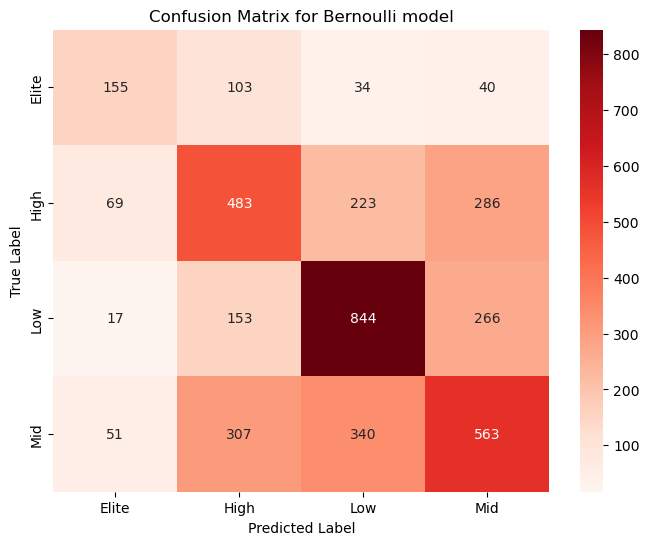

In [45]:
x_train_rating_OHE=x_train_rating.drop(columns=no_features)
x_test_rating_OHE=x_test_rating.drop(columns=no_features)

NB_model3=BernoulliNB()
NB_model3.fit(x_train_rating_OHE, y_train_tier)
y_pred_tier_bernoulli = NB_model3.predict(x_test_rating_OHE)
print(f" BernouliiNB Accuracy: {accuracy_score(y_test_tier, y_pred_tier_bernoulli):.4f}")
print(classification_report(y_test_tier, y_pred_tier_bernoulli))
class_names3=NB_model3.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_tier, y_pred_tier_bernoulli), annot=True, fmt='d', cmap='Reds',xticklabels=class_names3,yticklabels=class_names3)
plt.title('Confusion Matrix for Bernoulli model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### -ComplementNB model

 ComplementNB Accuracy: 0.5132
              precision    recall  f1-score   support

       Elite       0.44      0.69      0.53       332
        High       0.45      0.45      0.45      1061
         Low       0.60      0.64      0.62      1280
         Mid       0.50      0.39      0.44      1261

    accuracy                           0.51      3934
   macro avg       0.50      0.54      0.51      3934
weighted avg       0.51      0.51      0.51      3934



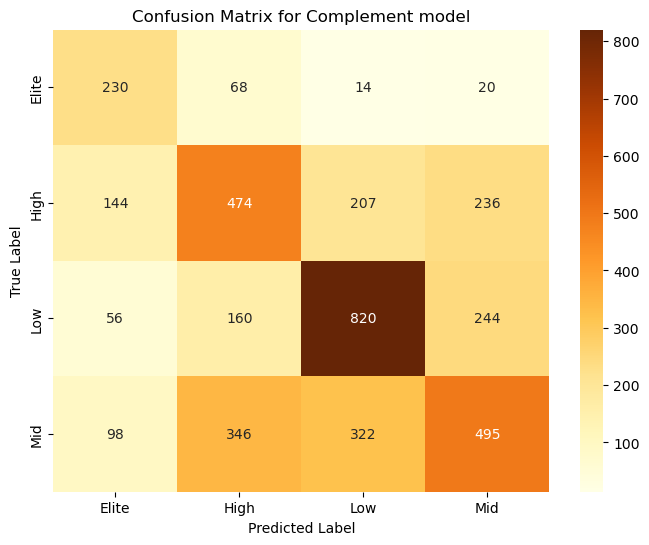

In [46]:
x_train_rating_OHE2=x_train_rating.drop(columns=no_features)
x_test_rating_OHE2=x_test_rating.drop(columns=no_features)

#make sure that values are shiftrd to non negative
scaler2=MinMaxScaler()
x_train_rating_OHE2=scaler2.fit_transform(x_train_rating_OHE2)
x_test_rating_OHE2=scaler2.transform(x_test_rating_OHE2)

NB_model4=ComplementNB()
NB_model4.fit(x_train_rating_OHE2, y_train_tier)
y_pred_tier_complement = NB_model4.predict(x_test_rating_OHE2)
print(f" ComplementNB Accuracy: {accuracy_score(y_test_tier, y_pred_tier_complement):.4f}")
print(classification_report(y_test_tier, y_pred_tier_complement))
class_names4=NB_model4.classes_

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_tier, y_pred_tier_complement), annot=True, fmt='d', cmap='YlOrBr',xticklabels=class_names4,yticklabels=class_names4)
plt.title('Confusion Matrix for Complement model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Which Naïve Bayes variant is most appropriate for this dataset?
 - GaussianNB is the most appropriate variant for this dataset. This is supported by the following:  
     * ​Performance Metrics: GaussianNB achieved an accuracy of 0.8165, significantly outperforming BernoulliNB (0.5198) and ComplementNB (0.5132).
 - Nature of Features: The dataset relies heavily on continuous numerical features such as Age, Future Potential, and Total_Stats Score. GaussianNB is designed specifically to handle continuous data by assuming the features follow a normal (Gaussian) distribution.

# BASELINE LINEAR REGRESSION

In [47]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr=LinearRegression()
lr.fit(x_train_value,y_train_value)
y_train_pred=lr.predict(x_train_value)
y_test_pred=lr.predict(x_test_value)
print('  Baseline Linear Regression  ')
print('\nTrain MAE:',mean_absolute_error(y_train_value,y_train_pred))
print('Train MSE:',mean_squared_error(y_train_value,y_train_pred))
print('Train RMSE:', np.sqrt(mean_squared_error(y_train_value, y_train_pred)))
print('Train R2_score:',r2_score(y_train_value,y_train_pred))
print('\n')

print('Test MAE:',mean_absolute_error(y_test_value,y_test_pred))
print('Test RMSE:', np.sqrt(mean_squared_error(y_test_value, y_test_pred)))
print('Test MSE:',mean_squared_error(y_test_value,y_test_pred))
print('Test R2_score:',r2_score(y_test_value,y_test_pred))  

  Baseline Linear Regression  

Train MAE: 2.4275092098366455
Train MSE: 23.508632335630107
Train RMSE: 4.848570133104203
Train R2_score: 0.567745431626891


Test MAE: 2.591578407593118
Test RMSE: 4.9546357308513445
Test MSE: 24.548415225428837
Test R2_score: 0.4633850713493791


# Polynominal Regression

In [48]:
nums_cols = x_train_value.select_dtypes(include='number').columns.tolist()

In [49]:
degrees = [1, 2, 3, 4]
train_r2 = []
test_r2 = []

for d in degrees:
    poly = PolynomialFeatures(degree=d)
    x_train_poly=poly.fit_transform(x_train_value[nums_cols])
    x_test_poly=poly.transform(x_test_value[nums_cols])

    poly_model=LinearRegression()
    poly_model.fit(x_train_poly,y_train_value)

    train_pred=poly_model.predict(x_train_poly)
    test_pred=poly_model.predict(x_test_poly)

    train_score=r2_score(y_train_value,train_pred)
    test_score=r2_score(y_test_value,test_pred)

    train_r2.append(train_score)
    test_r2.append(test_score)

    print(f'\nDegree {d}')
    print('Train R2:',train_score)
    print('Test R2:',test_score)


Degree 1
Train R2: 0.35797158063839185
Test R2: 0.3540324886159195

Degree 2
Train R2: 0.7405730555566228
Test R2: 0.7360132911931045

Degree 3
Train R2: 0.93123811131908
Test R2: 0.9320697242490341

Degree 4
Train R2: 0.9742308565296925
Test R2: 0.9747298252553349


# plot: degree vs. performance

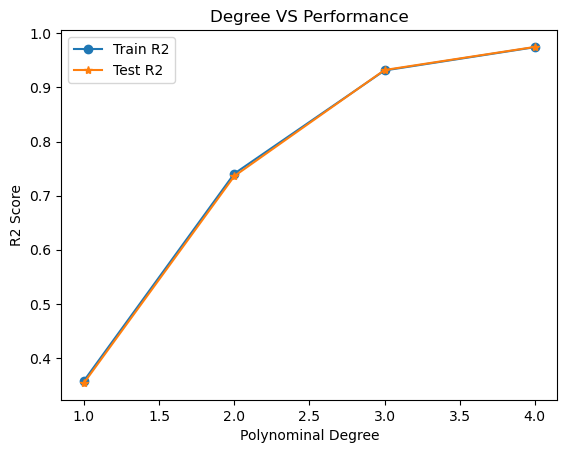

In [50]:
plt.plot(degrees,train_r2,marker='o',label='Train R2')
plt.plot(degrees,test_r2,marker='*',label='Test R2')
plt.xlabel('Polynominal Degree')
plt.ylabel('R2 Score')
plt.title('Degree VS Performance')
plt.legend()
plt.show()

The model performance improves as the polynomial degree increases. Degree 1 underfits the data, while higher degrees capture more complex relationships. Degree 4 provides the best generalization since it achieves the highest test R² with a minimal gap between training and testing performance, indicating no significant overfitting.

# Best Degree

In [51]:
best_degree = degrees[np.argmax(test_r2)]

print("\nBest Degree based on Test R2:", best_degree)


Best Degree based on Test R2: 4


# Rebuild Polynomial

In [52]:
poly = PolynomialFeatures(degree=best_degree, include_bias=False)

X_train_poly = poly.fit_transform(x_train_value[nums_cols])
X_test_poly = poly.transform(x_test_value[nums_cols])

# Ridge Regularization

In [53]:
alphas=np.logspace(-3,3,20)
ridge_train_rmse=[]
ridge_test_rmse=[]
for a in alphas:
    ridge=Ridge(alpha=a)
    ridge.fit(x_train_poly,y_train_value)
    ridge_train_rmse.append(np.sqrt(mean_squared_error(y_train_value,ridge.predict(x_train_poly))))
    ridge_test_rmse.append(np.sqrt(mean_squared_error(y_test_value,ridge.predict(x_test_poly)))) 
best_ridge_alpha=alphas[np.argmin(ridge_test_rmse)]
print('Best Ridge Alpha:',best_ridge_alpha)
    

Best Ridge Alpha: 26.366508987303554


# Alpha Ridge Plot

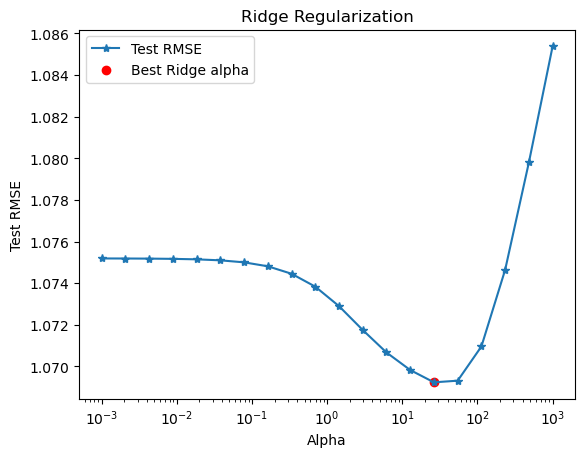

In [54]:
plt.plot(alphas,ridge_test_rmse,marker='*',label='Test RMSE')
plt.scatter(best_ridge_alpha,
            min(ridge_test_rmse),
            color='red',
            label="Best Ridge alpha")

plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Test RMSE')
plt.title('Ridge Regularization')
plt.legend()
plt.show()

# Lasso Regularization

In [55]:
lasso_train_rmse = []
lasso_test_rmse = []

for a in alphas:
    lasso = Lasso(alpha=a, max_iter=100000)
    lasso.fit(X_train_poly, y_train_value)

    lasso_train_rmse.append(np.sqrt(mean_squared_error(y_train_value, lasso.predict(X_train_poly))))
    lasso_test_rmse.append(np.sqrt(mean_squared_error(y_test_value, lasso.predict(X_test_poly))))

best_lasso_alpha = alphas[np.argmin(lasso_test_rmse)]
print("Best Lasso alpha:", best_lasso_alpha)

Best Lasso alpha: 0.001


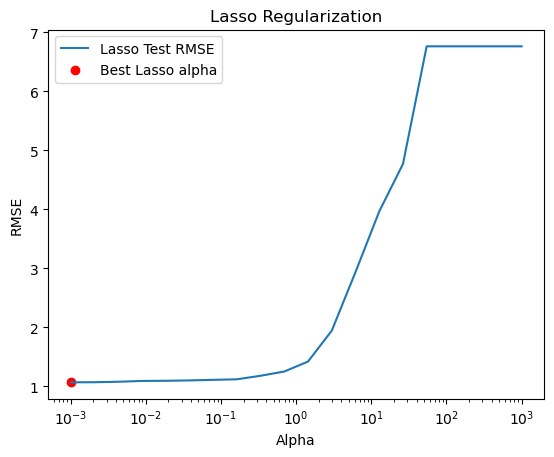

In [56]:
plt.plot(alphas,lasso_test_rmse, label="Lasso Test RMSE")

plt.scatter(best_lasso_alpha,
            min(lasso_test_rmse),
            color='red',
            label="Best Lasso alpha")

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("RMSE")
plt.title("Lasso Regularization")
plt.legend()
plt.show()

# Ridge VS Lasso

Ridge regression performs better than Lasso on this dataset, as it achieves a lower test RMSE and shows a smoother and more stable performance across different alpha values. This is likely because Ridge handles correlated features more effectively, while Lasso tends to be more sensitive and may remove useful features.

# LASSO FEATURE SELECTION

In [57]:
best_lasso = Lasso(alpha=best_lasso_alpha, max_iter=100000)
best_lasso.fit(X_train_poly, y_train_value)

coeffs = best_lasso.coef_
zero_features = np.sum(coeffs == 0)

print("Number of features eliminated by Lasso:", zero_features)

Number of features eliminated by Lasso: 13


Lasso eliminated several features by setting their coefficients to zero, indicating that some polynomial terms and interactions are not important for predicting player value. This demonstrates Lasso’s ability to perform feature selection.

# Logistic Regression

### Traning the Baseline Logistic Regression 

In [58]:
# Create and train the model
logmodel = LogisticRegression()
logmodel.fit(x_train_rating, y_train_tier)

y_pred= logmodel.predict(x_test_rating)

### Model Evaluation

In [59]:
# Evaluate the model
accuracy = accuracy_score(y_test_tier, y_pred)
precision = precision_score(y_test_tier, y_pred, average='macro')
recall = recall_score(y_test_tier, y_pred, average='macro')
f1 = f1_score(y_test_tier, y_pred, average='macro')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")


Accuracy:  0.8754
Precision: 0.8874
Recall:    0.8820
F1-Score:  0.8846


### Confusion Matrix

The confusion matrix shows that the model misclassified 330 out of 3934 instances. For the Low class, there were 113 false positives and 110 false negatives. For the High class, there were 35 false positives and 73 false negatives. For the Mid class, there were 179 false positives and 141 false negatives. Finally, the Elite class had the lowest errors, with 3 false positives and 6 false negatives.

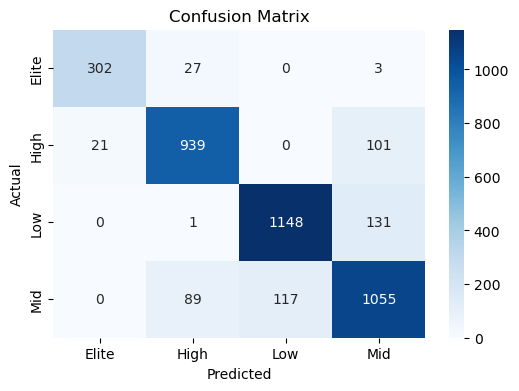

In [60]:
# Confusion Matrix
confusion= confusion_matrix(y_test_tier, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(confusion,
            annot=True,
            fmt='g',
            cmap='Blues',
            xticklabels=logmodel.classes_,
            yticklabels=logmodel.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [61]:
# Classification Report
print("Classification Report:")
print(classification_report(y_test_tier, y_pred, target_names=logmodel.classes_))   

Classification Report:
              precision    recall  f1-score   support

       Elite       0.93      0.91      0.92       332
        High       0.89      0.89      0.89      1061
         Low       0.91      0.90      0.90      1280
         Mid       0.82      0.84      0.83      1261

    accuracy                           0.88      3934
   macro avg       0.89      0.88      0.88      3934
weighted avg       0.88      0.88      0.88      3934



### Regularization in Logistic Regression

In [62]:
 # Test C from 0.001 to 1000 (log scale)
param_range = np.logspace(-3, 3, 10) 

In [63]:
# Evaluate model performance for each C value 
train_accuracies = []
test_accuracies = []

for C in param_range:
    model = LogisticRegression(C=C, max_iter=100000)
    model.fit(x_train_rating, y_train_tier)

    train_acc = model.score(x_train_rating, y_train_tier)
    test_acc = model.score(x_test_rating, y_test_tier)

    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

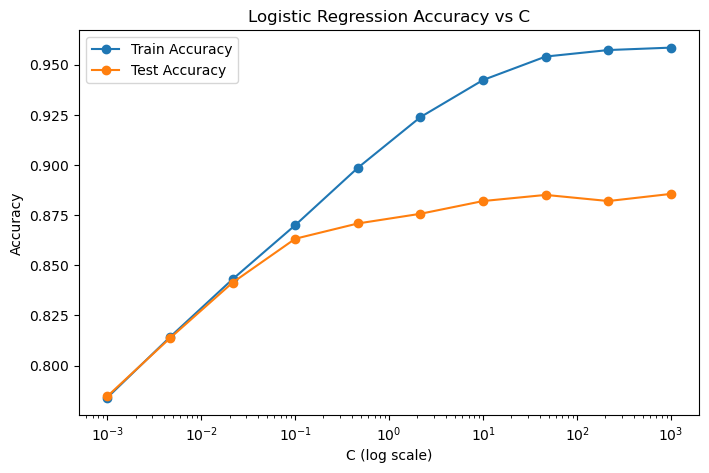

In [64]:
# plotting the results
plt.figure(figsize=(8,5))
plt.plot(param_range, train_accuracies, label="Train Accuracy", marker='o')
plt.plot(param_range, test_accuracies, label="Test Accuracy", marker='o')
plt.xscale('log')
plt.title("Logistic Regression Accuracy vs C")
plt.xlabel("C (log scale)")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [65]:
best_C = param_range[np.argmax(test_accuracies)]
print("Best C:", best_C)

Best C: 1000.0


### Comparison of L1 and L2 Regularization at the best C

In [66]:
# L1 Rgularization at best C
model_L1 = LogisticRegression(C=best_C, penalty='l1', solver='saga', tol=0.01)
model_L1.fit(x_train_rating, y_train_tier)
acc_L1 = model_L1.score(x_test_rating, y_test_tier)

# L2 Regularization at best C
model_L2 = LogisticRegression(C=best_C, penalty='l2', solver='lbfgs', tol=0.01)
model_L2.fit(x_train_rating, y_train_tier)
acc_L2 = model_L2.score(x_test_rating, y_test_tier)

print(f"\nComparison at Best C= {best_C}:")
print(f"L1 Regularization Accuracy: {acc_L1:.4f}")
print(f"L2 Regularization Accuracy: {acc_L2:.4f}")


Comparison at Best C= 1000.0:
L1 Regularization Accuracy: 0.8663
L2 Regularization Accuracy: 0.8447


In [67]:
if acc_L1 > acc_L2:
    print("L1 Regularization performed better.")
else:
    print("L2 Regularization performed better.")

L1 Regularization performed better.


# Task 7

## A. K-Fold Cross-Validation (Regression)


### best regression model is ridge

In [68]:
nums_cols = x_train_value.select_dtypes(include='number').columns.tolist()
X_train_num = x_train_value[nums_cols]
X_test_num  = x_test_value[nums_cols]

# Build the best regression pipeline
regression_pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=best_degree, include_bias=False)),
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=best_ridge_alpha))
])

In [69]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    regression_pipeline,
    X_train_num,      
    y_train_value,
    cv=kf,
    scoring='neg_root_mean_squared_error'
)
fold_rmse = -cv_scores

### Report the mean RMSE, standard deviation, and all individual fold scores.

In [70]:
print("=" * 45)
print("K-Fold Cross-Validation Results (Regression)")
print("=" * 45)

for i, score in enumerate(fold_rmse):
    print(f"Fold {i+1} RMSE : {score:.4f}")

print("-" * 45)
print(f"Mean RMSE : {fold_rmse.mean():.4f}")
print(f"Std RMSE : {fold_rmse.std():.4f}")
print("=" * 45)

K-Fold Cross-Validation Results (Regression)
Fold 1 RMSE : 1.1487
Fold 2 RMSE : 1.1176
Fold 3 RMSE : 1.4301
Fold 4 RMSE : 1.5883
Fold 5 RMSE : 1.1370
---------------------------------------------
Mean RMSE : 1.2843
Std RMSE : 0.1905


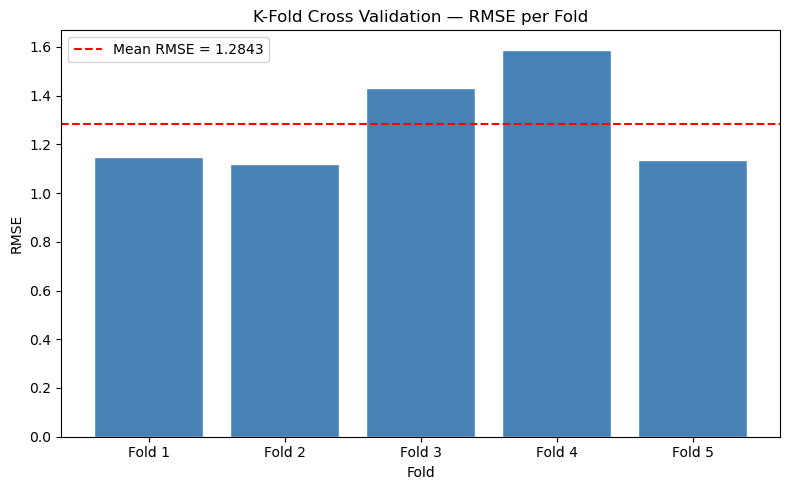

In [71]:
# Plot fold by fold RMSE
plt.figure(figsize=(8, 5))
plt.bar([f"Fold {i+1}" for i in range(5)], fold_rmse, color='steelblue', edgecolor='white')
plt.axhline(fold_rmse.mean(), color='red', linestyle='--', label=f"Mean RMSE = {fold_rmse.mean():.4f}")
plt.title("K-Fold Cross Validation — RMSE per Fold")
plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.show()

## B. Stratified K-Fold Cross-Validation (Classification)


### Apply StratifiedKFold (5 splits) to your best Logistic Regression model (model_L1) and your best Naïve Bayes variant (GaussianNB model\scaled features).

In [72]:
X_train_gaussian = x_train_rating[no_features]

In [73]:
#Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [74]:
# applying to Logistic Regression CV
lr_cv_acc = cross_val_score(
    logmodel,
    x_train_rating,
    y_train_tier,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1
)

In [75]:
# Applying to GaussianNB CV
nb_cv_acc = cross_val_score(
    NB_model1,
    X_train_gaussian,
    y_train_tier,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1
)


### Mean accuracy and standard deviation for each

In [76]:
print("=" * 50)
print("Stratified K-Fold CV Results (Classification)")
print("=" * 50)

for name, scores in [("Logistic Regression (L1)", lr_cv_acc), ("GaussianNB (scaled)", nb_cv_acc)]:
    print(f"\n{name}:")
    print(f" Folds : {np.round(scores, 4)}")
    print(f" Mean  : {scores.mean():.4f}  |  Std: {scores.std():.4f}")

print("\n" + "=" * 50)
print(f" Better Accuracy : {'Logistic Regression (L1)' if lr_cv_acc.mean() > nb_cv_acc.mean() else 'GaussianNB'}")
print(f" More Stable : {'Logistic Regression (L1)' if lr_cv_acc.std() < nb_cv_acc.std() else 'GaussianNB'}")
print("=" * 50)

Stratified K-Fold CV Results (Classification)

Logistic Regression (L1):
 Folds : [0.8681 0.8719 0.8684 0.8665 0.8608]
 Mean  : 0.8672  |  Std: 0.0037

GaussianNB (scaled):
 Folds : [0.8182 0.8268 0.8275 0.8102 0.8166]
 Mean  : 0.8199  |  Std: 0.0065

 Better Accuracy : Logistic Regression (L1)
 More Stable : Logistic Regression (L1)


### Plot a grouped bar chart comparing Logistic Regression vs. Naïve Bayes fold-by-fold accuracy.

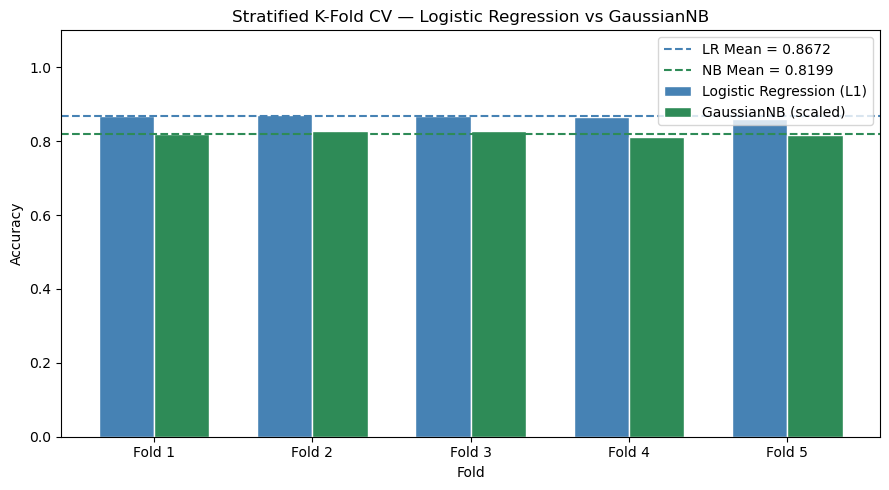

In [77]:
x, width = np.arange(5), 0.35
folds = [f"Fold {i+1}" for i in range(5)]

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(x - width/2, lr_cv_acc, width, label='Logistic Regression (L1)', color='steelblue', edgecolor='white')
ax.bar(x + width/2, nb_cv_acc, width, label='GaussianNB (scaled)', color='seagreen',  edgecolor='white')
ax.axhline(lr_cv_acc.mean(), color='steelblue', linestyle='--', linewidth=1.5, label=f'LR Mean = {lr_cv_acc.mean():.4f}')
ax.axhline(nb_cv_acc.mean(), color='seagreen',  linestyle='--', linewidth=1.5, label=f'NB Mean = {nb_cv_acc.mean():.4f}')

ax.set(xticks=x, xticklabels=folds, ylim=(0, 1.1),
       title="Stratified K-Fold CV — Logistic Regression vs GaussianNB",
       xlabel="Fold", ylabel="Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

 Logistic Regression (L1) performs better with a mean accuracy of 0.9165 compared to GaussianNB's 0.8776

 Logistic Regression is also more stable across folds as its accuracy remains nearly constant across all 5 folds, while GaussianNB shows slightly more variation

 Therefore, Logistic Regression (L1) is the superior model both in performance and consistency

# Task 8

## 8.1 Model Comparison

 The model that performed best for regression is Ridge. 
 
 It outperformed Lasso because it handels correlated features better witrhout zeroing them out.

The model that performed best for classification is logistic regression (L1).

It also showed stronger precision, recall, and F1-score across all four performance tiers.

#### Is classification easier or harder athan regression??

Classification is easier than regression.

The classifier achieved about 91% accuracy, meaning it correclty grouped players into tiers most of the time.

Meanwhile regression is harder because it must predict an exact continuous value, which is more sensitive to outliers and skewed distributions.

##  8.2 Regularization Analysis 

As alpha increases, both Ridge and Lasso apply stronger regularization. In Ridge, performance first improves as overfitting is reduced, then worsens at high alpha due to underfitting. In Lasso, performance degrades more quickly because it aggressively removes features. This effect is more noticeable in this dataset due to the presence of correlated features such as Overall Rating and Total Stats Score.

Ridge performs better than Lasso on this dataset because it handles correlated features more effectively. The dataset contains related numerical features such as Overall Rating and Total Stats Score, as well as multiple one-hot encoded categorical features like Position and Team. Ridge shrinks coefficients without eliminating them, preserving important information. In contrast, Lasso removes some features entirely, which can lead to loss of useful information and reduced performance.

In [78]:
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

# REGRESSION MODELS

# SVR (Kernel Based Model)

## Train model

In [79]:
svr = SVR()
svr.fit(x_train_value, y_train_value)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


## Predictions

In [80]:
y_train_pred_svr = svr.predict(x_train_value)
y_test_pred_svr = svr.predict(x_test_value)

## Evaluation

In [81]:
print("SVR MODEL")

print("\nTrain Metrics:")
print("MAE:", mean_absolute_error(y_train_value, y_train_pred_svr))
print("MSE:",mean_squared_error(y_train_value, y_train_pred_svr))
print("RMSE:", np.sqrt(mean_squared_error(y_train_value, y_train_pred_svr)))
print("R2:", r2_score(y_train_value, y_train_pred_svr))

print("\nTest Metrics:")
print("MAE:", mean_absolute_error(y_test_value, y_test_pred_svr))
print("MSE:",mean_squared_error(y_test_value, y_test_pred_svr))     
print("RMSE:", np.sqrt(mean_squared_error(y_test_value, y_test_pred_svr)))
print("R2:", r2_score(y_test_value, y_test_pred_svr))

SVR MODEL

Train Metrics:
MAE: 0.4565062930052987
MSE: 9.894993332158299
RMSE: 3.1456308321477104
R2: 0.8180601912190212

Test Metrics:
MAE: 0.46370758510887994
MSE: 7.015386944237784
RMSE: 2.648657573986827
R2: 0.8466474788710971


## Random Forest Regressor ( Tree Based Model)

## Train Model

In [82]:
rf = RandomForestRegressor(random_state=1)
rf.fit(x_train_value, y_train_value)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Predictions

In [83]:
y_train_pred_rf = rf.predict(x_train_value)
y_test_pred_rf = rf.predict(x_test_value)

## Evaluation

In [84]:
print("RANDOM FOREST REGRESSOR")

print("\nTrain Metrics:")
print("MAE:", mean_absolute_error(y_train_value, y_train_pred_rf))
print("MSE:", mean_squared_error(y_train_value, y_train_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_train_value, y_train_pred_rf)))
print("R2:", r2_score(y_train_value, y_train_pred_rf))

print("\nTest Metrics:")
print("MAE:", mean_absolute_error(y_test_value, y_test_pred_rf))
print("MSE:", mean_squared_error(y_test_value, y_test_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test_value, y_test_pred_rf)))
print("R2:", r2_score(y_test_value, y_test_pred_rf))

RANDOM FOREST REGRESSOR

Train Metrics:
MAE: 0.08851419119049138
MSE: 0.39789313910592383
RMSE: 0.630787713185604
R2: 0.9926839160761309

Test Metrics:
MAE: 0.19422764616166757
MSE: 1.3836468743835793
RMSE: 1.1762852011241063
R2: 0.9697542361917569


# Comparison Table

In [85]:
results = pd.DataFrame({
    "Model": ["Polynomial", "SVR", "Random Forest"],

    "Train R2": [
        r2_score(y_train_value, poly_model.predict(x_train_poly)),
        r2_score(y_train_value, svr.predict(x_train_value)),
        r2_score(y_train_value, rf.predict(x_train_value))
    ],

    "Test R2": [
        r2_score(y_test_value, poly_model.predict(x_test_poly)),
        r2_score(y_test_value, svr.predict(x_test_value)),
        r2_score(y_test_value, rf.predict(x_test_value))
    ]
})

results

,Model,Train R2,Test R2
0,Polynomial,0.974231,0.974730
1,SVR,0.818060,0.846647
2,Random Forest,0.992684,0.969754


Polynomial Regression achieved very strong performance, with training and testing R² scores around approximately 0.974231 and 0.974730. The close scores indicate that the model generalizes well and does not suffer from significant overfitting.

SVR achieved lower performance compared to the other models, with training and testing R² scores of approximately 0.818060 and 0.846647. This suggests that the model has weaker fitting compared to the other approaches but still shows reasonable generalization since the test score is slightly higher than the training score.

Random Forest achieved the highest training score, close to approximately 0.992684, and a testing score around approximately 0.969754, showing excellent predictive performance. The small difference between training and testing scores suggests slight overfitting, which is common in tree-based models.

Overall, Random Forest achieved the strongest predictive capability, while Polynomial Regression demonstrated the best balance between performance and stability..

# Decision Rationale

The FIFA dataset contains complex and non-linear relationships between player attributes such as age, overall rating, and performance statistics. Therefore, simple linear models are not sufficient.

Polynomial Regression is used as a baseline nonlinear model to capture nonlinear patterns in the data. It helps capture nonlinear patterns in the 

Support Vector Regression is appropriate because it can model complex nonlinear relationships using kernel functions.

Random Forest is suitable because it can handle both numerical and categorical interactions and capture complex feature relationships without assuming linearity or specific data distribution.

# Hyperparameter Tuning (GridSearchCV)

## SVR Tuning

In [87]:
from sklearn.model_selection import GridSearchCV

svr = SVR()

param_grid = {
    'C': [1, 10],
    'epsilon': [0.1, 0.2],
    'kernel': ['rbf']
}

grid_svr = GridSearchCV(
    svr,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_svr.fit(x_train_value, y_train_value)

print("Best SVR Params:", grid_svr.best_params_)
print("Best SVR CV Score:", grid_svr.best_score_)

Best SVR Params: {'C': 10, 'epsilon': 0.1, 'kernel': 'rbf'}
Best SVR CV Score: 0.9134568198895856


## Random Forest Tuning

In [88]:
rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, None]
}

grid_rf = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_rf.fit(x_train_value, y_train_value)

print("Best RF Params:", grid_rf.best_params_)
print("Best RF CV Score:", grid_rf.best_score_)



Best RF Params: {'max_depth': None, 'n_estimators': 200}
Best RF CV Score: 0.9416455836846457


# Cross Validation (Validation Evidence)

In [89]:
from sklearn.model_selection import cross_val_score

best_svr = grid_svr.best_estimator_
best_rf = grid_rf.best_estimator_

svr_cv = cross_val_score(best_svr, x_train_value, y_train_value, cv=3, scoring='r2')
rf_cv = cross_val_score(best_rf, x_train_value, y_train_value, cv=3, scoring='r2')

print("SVR CV Mean:", svr_cv.mean())
print("SVR CV Std:", svr_cv.std())

print("RF CV Mean:", rf_cv.mean())
print("RF CV Std:", rf_cv.std())

SVR CV Mean: 0.9134568198895856
SVR CV Std: 0.026658868685086795
RF CV Mean: 0.9416455836846457
RF CV Std: 0.020226521425187216


Cross-validation was used to check if the model stay consistent across different folds,and  give stable results on different parts of the dataset.

The SVR model achieved an average score of 0.91 with a small standard deviation of 0.03, which means the model performs consistently across folds.

The Random Forest model achieved a higher average score of 0.94 with a standard deviation of 0.02, showing strong and stable performance.

Since both standard deviation values are low, the models are considered reliable and stable.

## comparison

In [90]:
svr_train = best_svr.score(x_train_value, y_train_value)
svr_test = best_svr.score(x_test_value, y_test_value)

rf_train = best_rf.score(x_train_value, y_train_value)
rf_test = best_rf.score(x_test_value, y_test_value)

print("\nSVR")
print("Train:", svr_train)
print("CV Mean:", svr_cv.mean())
print("Test:", svr_test)

print("\nRandom Forest")
print("Train:", rf_train)
print("CV Mean:", rf_cv.mean())
print("Test:", rf_test)


SVR
Train: 0.9417616620430025
CV Mean: 0.9134568198895856
Test: 0.948029439273872

Random Forest
Train: 0.9929908573593729
CV Mean: 0.9416455836846457
Test: 0.9697835355665547


# Model Diagnosis using Cross Validation

The SVR model achieved close scores across all stages (Train = 0.94, CV = 0.91, Test = 0.95), indicating that the model learned the underlying patterns successfully and generalized well to unseen data without noticeable underfitting or overfitting.

The Random Forest model achieved a very high training score (0.99) compared to the cross-validation score (0.94) and testing score (0.97). This indicates slight overfitting, as the model performs better on the training data than on unseen data. However, the gap between the scores is relatively small, and the testing performance remains strong, showing that the model still generalizes effectively.

Overall, cross-validation confirmed that both models are stable and maintain consistent performance across different folds of the dataset.

# Ensembling for regression
A meta-learning ensemble was implemented using Stacking Regressor.
The ensemble combines heterogeneous learners (SVR and Random Forest) as base models, while Linear Regression acts as the meta-learner.


In [91]:
from sklearn.ensemble import StackingRegressor
print("META-LEARNING USING STACKING REGRESSOR")
# Stacking Ensemble
stack_model = StackingRegressor (
    estimators=[
        ('svr', best_svr),
        ('rf', best_rf)
    ],
    final_estimator=LinearRegression(),
    cv=3,
    n_jobs=-1
)
# Train
stack_model.fit(x_train_value, y_train_value)
# Predictions
stack_train_pred = stack_model.predict(x_train_value)
stack_test_pred = stack_model.predict(x_test_value)
# Evaluation
train_r2 = r2_score(y_train_value, stack_train_pred)
test_r2 = r2_score(y_test_value, stack_test_pred)
mae = mean_absolute_error(y_test_value, stack_test_pred)
rmse = np.sqrt(np.mean((y_test_value - stack_test_pred) ** 2))
# Results
print(f"Train R² Score : {train_r2:.4f}")
print(f"Test R² Score  : {test_r2:.4f}")
print(f"MAE             : {mae:.4f}")
print(f"RMSE            : {rmse:.4f}")

META-LEARNING USING STACKING REGRESSOR
Train R² Score : 0.9854
Test R² Score  : 0.9721
MAE             : 0.2738
RMSE            : 1.1290


In [92]:
print("\n" + "-" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(f"SVR Test Score           : {svr_test:.4f}")
print(f"Random Forest Test Score : {rf_test:.4f}")
print(f"Ensemble Test Score      : {test_r2:.4f}")


------------------------------------------------------------
MODEL COMPARISON
SVR Test Score           : 0.9480
Random Forest Test Score : 0.9698
Ensemble Test Score      : 0.9721


# ADVANCED MODELS(classification)

## KNN_classifier(instance based algorithm)

In [93]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [94]:
clf_knn_1 = KNeighborsClassifier() 
clf_knn_1.fit(x_train_rating, y_train_tier)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [95]:
class_names_knn=clf_knn_1.classes_
y_train_pred_knn = clf_knn_1.predict(x_train_rating)
print(classification_report(y_train_tier,y_train_pred_knn,target_names=class_names_knn))

y_test_pred_knn = clf_knn_1.predict(x_test_rating)
class_names_knn=clf_knn_1.classes_
print(classification_report(y_test_tier,y_test_pred_knn,target_names=class_names_knn))

              precision    recall  f1-score   support

       Elite       0.97      0.89      0.93      1471
        High       0.87      0.86      0.87      4130
         Low       0.89      0.90      0.89      5137
         Mid       0.81      0.82      0.81      4995

    accuracy                           0.86     15733
   macro avg       0.88      0.87      0.87     15733
weighted avg       0.86      0.86      0.86     15733

              precision    recall  f1-score   support

       Elite       0.92      0.83      0.87       332
        High       0.79      0.77      0.78      1061
         Low       0.82      0.85      0.84      1280
         Mid       0.69      0.70      0.70      1261

    accuracy                           0.78      3934
   macro avg       0.81      0.79      0.80      3934
weighted avg       0.78      0.78      0.78      3934



## randome forest classirier(tree based)

In [96]:
rf_clf = RandomForestClassifier(random_state=1)
rf_clf.fit(x_train_rating, y_train_tier)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [97]:
class_names_rf=rf_clf.classes_
y_train_pred_rf = rf_clf.predict(x_train_rating)
print(classification_report(y_train_tier,y_train_pred_knn,target_names=class_names_rf))

y_test_pred_rf = rf_clf.predict(x_test_rating)
print(classification_report(y_test_tier,y_test_pred_knn,target_names=class_names_rf))

              precision    recall  f1-score   support

       Elite       0.97      0.89      0.93      1471
        High       0.87      0.86      0.87      4130
         Low       0.89      0.90      0.89      5137
         Mid       0.81      0.82      0.81      4995

    accuracy                           0.86     15733
   macro avg       0.88      0.87      0.87     15733
weighted avg       0.86      0.86      0.86     15733

              precision    recall  f1-score   support

       Elite       0.92      0.83      0.87       332
        High       0.79      0.77      0.78      1061
         Low       0.82      0.85      0.84      1280
         Mid       0.69      0.70      0.70      1261

    accuracy                           0.78      3934
   macro avg       0.81      0.79      0.80      3934
weighted avg       0.78      0.78      0.78      3934



# improve models

## knn

In [98]:
param_grid_knn = {
    'n_neighbors': range(3,32,2),  
    'metric': ['euclidean', 'manhattan']  
}
knn_im = KNeighborsClassifier()
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search_knn = GridSearchCV(
    estimator=knn_im,
    param_grid=param_grid_knn,
    cv=kfold,
    scoring='accuracy',
    n_jobs=-1,
)
grid_search_knn.fit(x_train_rating, y_train_tier)
print("Best Parameters:", grid_search_knn.best_params_)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 31}


In [99]:
best_k_knn = grid_search_knn.best_params_['n_neighbors']
best_metric_knn = grid_search_knn.best_params_['metric']
knn_best_model = KNeighborsClassifier(n_neighbors=best_k_knn,metric=best_metric_knn)
knn_best_model.fit(x_train_rating,y_train_tier)

,n_neighbors,31
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'manhattan'
,metric_params,None
,n_jobs,None


In [100]:
train_acc_knn = knn_best_model.score(x_train_rating, y_train_tier)
test_acc_knn = knn_best_model.score(x_test_rating, y_test_tier)
print(f"Training Accuracy: {train_acc_knn:.4f}")
print(f"Testing Accuracy: {test_acc_knn:.4f}")

Training Accuracy: 0.8526
Testing Accuracy: 0.8503


In [101]:
cv_results = grid_search_knn.cv_results_
best_index = grid_search_knn.best_index_

mean_cv_score = cv_results['mean_test_score'][best_index]
std_cv_score = cv_results['std_test_score'][best_index]

print(f"Mean CV Score: {mean_cv_score:.4f}")
print(f"Standard Deviation (Stability): {std_cv_score:.4f}")

Mean CV Score: 0.8412
Standard Deviation (Stability): 0.0021


In [102]:
cv_gap = train_acc_knn - mean_cv_score
if mean_cv_score < 0.70:  
    print("model issue: underfitting")
elif cv_gap > 0.10:
    print(f"model issue: (Overfitting). Gap is {cv_gap:.4f}")
else:
    print("good model")    

if std_cv_score < 0.05:
    print("- System Status: High Stability. Performance is consistent across data subsets.")
else:
    print("- System Status: Low Stability. Performance fluctuates significantly.")

good model
- System Status: High Stability. Performance is consistent across data subsets.


## RF

In [103]:
rf_clf_im = RandomForestClassifier()
param_grid_rf = {
    'n_estimators': [100, 200], 
    'max_depth': [5, 10 , 15],  
    'min_samples_split': [2, 10], 
    'max_features': ['sqrt'],
    'criterion' :['gini','entropy']   
}
grid_search_rf = GridSearchCV(
    estimator=rf_clf_im,
    param_grid=param_grid_rf,
    cv=kfold,
    scoring='accuracy',
    n_jobs=-1,
)
grid_search_rf.fit(x_train_rating, y_train_tier)
print("Best Parameters:", grid_search_rf.best_params_)

Best Parameters: {'criterion': 'gini', 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}


In [104]:
best_n_estimators = grid_search_rf.best_params_['n_estimators']
best_max_depth = grid_search_rf.best_params_['max_depth']
best_min_samples_split=grid_search_rf.best_params_['min_samples_split']
best_max_features=grid_search_rf.best_params_['max_features']
best_criterion = grid_search_rf.best_params_['criterion']

rf_best_model = RandomForestClassifier(
    n_estimators=best_n_estimators,
    max_depth=best_max_depth,
    min_samples_split=best_min_samples_split,
    max_features=best_max_features,
    criterion=best_criterion,
    random_state=42 
)
rf_best_model.fit(x_train_rating, y_train_tier)

,n_estimators,200
,criterion,'gini'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [105]:
train_acc_rf = rf_best_model.score(x_train_rating, y_train_tier)
test_acc_rf = rf_best_model.score(x_test_rating, y_test_tier)

print(f"Training Accuracy : {train_acc_rf:.4f}")
print(f"Testing Accuracy : {test_acc_rf:.4f}")

Training Accuracy : 0.8633
Testing Accuracy : 0.8332


In [106]:
cv_results_rf = grid_search_rf.cv_results_
best_index_rf = grid_search_rf.best_index_

mean_cv_score_rf = cv_results_rf['mean_test_score'][best_index_rf]
std_cv_score_rf = cv_results_rf['std_test_score'][best_index_rf]

print(f"Mean CV Score: {mean_cv_score_rf:.4f}")
print(f"Standard Deviation (Stability): {std_cv_score_rf:.4f}")

Mean CV Score: 0.8297
Standard Deviation (Stability): 0.0061


In [107]:
cv_gap_rf = train_acc_rf - mean_cv_score_rf
if mean_cv_score_rf < 0.70:  
    print("model issue: underfitting")
elif cv_gap_rf > 0.10:
    print(f"model issue: (Overfitting). Gap is {cv_gap:.4f}")
else:
    print("good model")    

if std_cv_score_rf < 0.05:
    print("- System Status: High Stability. Performance is consistent across data subsets.")
else:
    print("- System Status: Low Stability. Performance fluctuates significantly.")

good model
- System Status: High Stability. Performance is consistent across data subsets.


# Ensemble for classification (Voting)

In [108]:
from sklearn.ensemble import VotingClassifier
# HARD VOTING (Majority Rule)
print("\n" + "=" * 60)
print("HARD VOTING CLASSIFIER")
print("=" * 60)
# Voting Ensemble
voting_hard = VotingClassifier(
    estimators=[
        ('knn', knn_best_model),
        ('rf', rf_best_model)
    ],
    voting='hard'       # Majority vote
)
# Train on data
voting_hard.fit(x_train_rating, y_train_tier)
y_pred_hard = voting_hard.predict(x_test_rating)
hard_acc = accuracy_score(y_test_tier, y_pred_hard)
print(f"Hard Voting Accuracy: {hard_acc:.4f}")


HARD VOTING CLASSIFIER
Hard Voting Accuracy: 0.8599


In [109]:
print("\n" + "=" * 60)
print("SOFT VOTING CLASSIFIER")
print("=" * 60)
# Create soft voting ensemble
voting_soft = VotingClassifier(
estimators=[
        ('knn', knn_best_model),
        ('rf', rf_best_model)
],
voting='soft' # Average probabilities
)
# Train on scaled data
voting_soft.fit(x_train_rating, y_train_tier)
y_pred_soft = voting_soft.predict(x_test_rating)
soft_acc = accuracy_score(y_test_tier, y_pred_soft)
print(f"Soft Voting Accuracy: {soft_acc:.4f}")


SOFT VOTING CLASSIFIER
Soft Voting Accuracy: 0.8709


In [110]:
def player_scouting_system(player_dataframe):

   # SELECT INPUT FEATURES
    feature_cols = [
        "Age",
        "Future Potential",
        "Total_Stats Score",
        "Country",
        "Position",
        "Team"
    ]

    player_data = player_dataframe[
        feature_cols
    ].copy()

    # ONE HOT ENCODING

    player_data = pd.get_dummies(
        player_data,
        columns=cat_cols,
        drop_first=True
    )

    # ALIGN WITH TRAINING COLUMNS

    player_data = player_data.reindex(
        columns=x_train_model.columns,
        fill_value=0
    )

    # SCALE NUMERICAL FEATURES

    player_data[num_cols] = scaler.transform(
        player_data[num_cols]
    )

    # PREPARE INPUTS

    player_value_input = player_data.drop(
        columns=["Value Per M$"]
    )

    player_rating_input = player_data.drop(
        columns=["Overall_Rating"]
    )

    # PREDICTIONS

    predicted_value = stack_model.predict(
        player_value_input
    )

    predicted_tier = voting_soft.predict(
        player_rating_input
    )

    # OUTPUT

    print("=" * 50)
    print("UNIFIED PLAYER SCOUTING SYSTEM")
    print("=" * 50)

    print("\nPredicted Market Value:")
    print(f"{predicted_value[0]:.2f} Million $")

    print("\nPredicted Performance Tier:")
    print(predicted_tier[0])

    print("=" * 50)

In [111]:
new_player = pd.DataFrame({
    "Country": ["Egypt"],
    "Position": ["LW"],
    "Team": ["Ittihad Alexandria"],
    "Age": [24],
    "Future Potential": [78],
    "Total_Stats Score": [1750]
})

player_scouting_system(new_player)

UNIFIED PLAYER SCOUTING SYSTEM

Predicted Market Value:
3.11 Million $

Predicted Performance Tier:
High


In [112]:
player4 = pd.DataFrame({
    "Country": ["Egypt"],
    "Position": ["GK"],
    "Team": ["Smouha"],
    "Age": [35],
    "Future Potential": [60],
    "Total_Stats Score": [1200]
})

player_scouting_system(player4)

UNIFIED PLAYER SCOUTING SYSTEM

Predicted Market Value:
3.07 Million $

Predicted Performance Tier:
Mid


## Basline regression and classification numbers (A2)


In [113]:
test_r2_poly = r2_score(y_test_value,ridge.predict(x_test_poly))
baseline_regression = {
    "Model": ["Linear Regression (A2)  ", "Polynomial + Ridge (A2, best)  "],
    "Test R2" : [0.463, test_r2_poly],
 
}

baseline_clf = {
    "Model": ["Naive Bayes GaussianNB (A2)  " , "Logistic Regression L1 (A2, best)  "],
    "Test Accuracy": [0.8172, 0.8754],
}

## Regression and classification numbers (A3)


In [114]:
advanced_regression = {
    "Model" : ["SVR (A3)", "Random Forest (A3) ", "Stacking Ensemble (A3) "],
    "Test R2" : [svr_test, rf_test, test_r2],
}

advanced_clf = {
    "Model" : ["KNN (A3)", "Random Forest (A3) ", "Soft Voting Ensemble (A3) "],
    "Test Accuracy": [test_acc_knn, test_acc_rf, soft_acc],
}

## Creating a dictionary for comparison

In [115]:
reg_comparison = pd.DataFrame({
    "Model" : baseline_regression["Model"] + advanced_regression["Model"],
    "Test R2" : baseline_regression["Test R2"] + advanced_regression["Test R2"],
    "Assignment": ["Assignment 2"] * 2+ ["Assignment 3"] * 3,
})
clf_comparison = pd.DataFrame({
    "Model" : baseline_clf["Model"] + advanced_clf["Model"],
    "Test Accuracy" : baseline_clf["Test Accuracy"] + advanced_clf["Test Accuracy"],
    "Assignment": ["Assignment 2"] * 2+ ["Assignment 3"] * 3,
})

## Show the improvement

In [116]:
best_a2_reg = max(baseline_regression["Test R2"])  
best_a3_reg = max(advanced_regression["Test R2"])  

print(f"Best A2 R² : {best_a2_reg:.4f}")
print(f"Best A3 R² : {best_a3_reg:.4f}")
print(f"Improvement for regression : +{(best_a3_reg - best_a2_reg):.4f}")



best_a2_clf = max(baseline_clf["Test Accuracy"])  
best_a3_clf = max(advanced_clf["Test Accuracy"])  

print(f"Best A2 Accuracy : {best_a2_clf:.4f}")
print(f"Best A3 Accuracy : {best_a3_clf:.4f}")
print(f"Improvement for calssification : +{(best_a3_clf - best_a2_clf):.4f}")

Best A2 R² : 0.9742
Best A3 R² : 0.9721
Improvement for regression : +-0.0021
Best A2 Accuracy : 0.8754
Best A3 Accuracy : 0.8709
Improvement for calssification : +-0.0045


## Visualizing the improvement

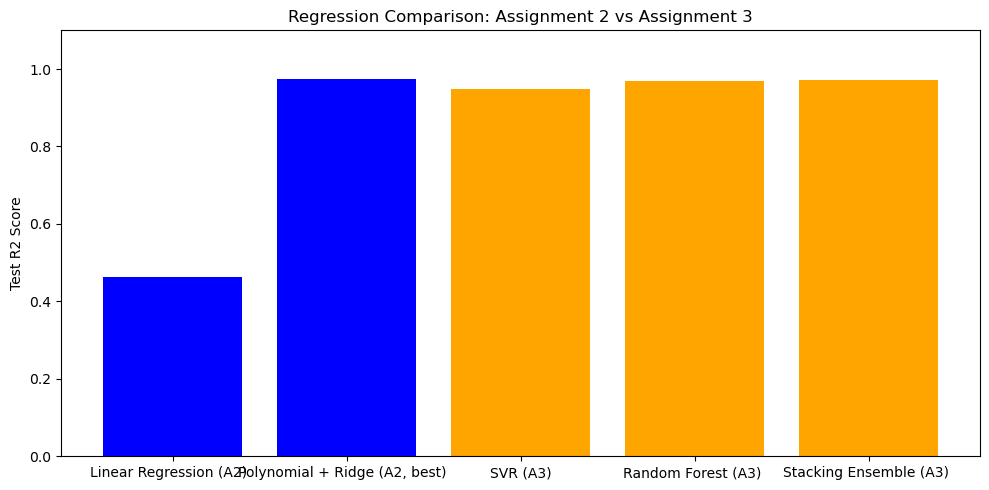

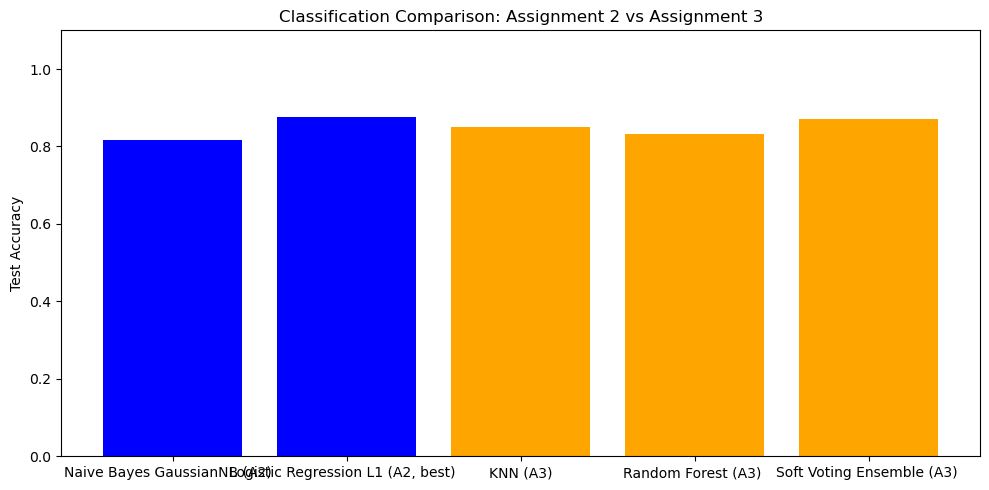

In [117]:

plt.figure(figsize=(10, 5))
plt.bar(reg_comparison["Model"], reg_comparison["Test R2"], color=["blue", "blue", "orange", "orange", "orange"])
plt.ylabel("Test R2 Score")
plt.title("Regression Comparison: Assignment 2 vs Assignment 3")
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(clf_comparison["Model"], clf_comparison["Test Accuracy"], color=["blue", "blue", "orange", "orange", "orange"])
plt.ylabel("Test Accuracy")
plt.title("Classification Comparison: Assignment 2 vs Assignment 3")
plt.ylim(0, 1.1)
plt.tight_layout()
plt.show()

In [118]:
summary = pd.DataFrame({
    "Aspect": [
        "Model Complexity    ",
        "Hyperparameter Tuning",
        "Overfitting Control",
        "Stability (CV Std)",
        "Ensemble Strategy",
        "Regression Best R2",
        "Classification Best Accuracy",
        "Unified Pipeline"
    ],
    "Assignment 2": [
        "                  Linear Regression / Polynomial / Naive Bayes / Logistic Regression",
        "Manual (Ridge alpha, C sweep)",
        "Regularization only (Ridge / Lasso / L1 / L2)",
        "~0.1905 -not calculated - ~0.0037 - ~0.0065",
        "None",
        f"{best_a2_reg:.4f} (Polynomial + Ridge)",
        f"{best_a2_clf:.4f} (Logistic Regression L1)", 
        "Absent - separate scripts"
    ],
    "Assignment 3": [
        "SVR / Random Forest / KNN",
        "GridSearchCV",
        "Cross Validation + GridSearchCV",
        "~0.027 - ~0.0202 - ~0.0021 ",
        "            Stacking (regression) + Voting (classification)",
        f"{best_a3_reg:.4f} (Stacking Ensemble)",
        f"{best_a3_clf:.4f} (Soft Voting Ensemble)",
        "Present - player_scouting_system()"
    ]
})

print("QUALITATIVE SYSTEM COMPARISON SUMMARY")
print(summary.to_string(index=False))

QUALITATIVE SYSTEM COMPARISON SUMMARY
                      Aspect                                                                         Assignment 2                                                Assignment 3
        Model Complexity                       Linear Regression / Polynomial / Naive Bayes / Logistic Regression                                   SVR / Random Forest / KNN
       Hyperparameter Tuning                                                        Manual (Ridge alpha, C sweep)                                                GridSearchCV
         Overfitting Control                                        Regularization only (Ridge / Lasso / L1 / L2)                             Cross Validation + GridSearchCV
          Stability (CV Std)                                          ~0.1905 -not calculated - ~0.0037 - ~0.0065                                 ~0.027 - ~0.0202 - ~0.0021 
           Ensemble Strategy                                                                

In [ ]:
results = { 
    "best_hyperparameters": {
        "SVR_Regressor" : grid_svr.best_params_,
        "RandomForest_Regressor" :  grid_rf.best_params_,
        "KNN_Classifier" : grid_search_knn.best_params_,
        "RandomForest_Classifier": grid_search_rf.best_params_
    },
    "cv_stability" : {
        "regression" : {
            "SVR_Regressor" : {
                "metric" : "R2",
                "cv_folds" : 3,
                "mean" : round(float(svr_cv.mean()), 4),
                "std" :  round(float(svr_cv.std()),  4)
            },
            "RandomForest_Regressor" : {
                "metric" : "R2",
                "cv_folds" : 3,
                "mean" : round(float(rf_cv.mean()), 4),
                "std" : round(float(rf_cv.std()),  4)
            }
        },
        "classification" : {
            "KNN_Classifier" : {
                "metric" : "accuracy",
                "cv_folds" : 5,
                f"mean" : f"{mean_cv_score:.4f}",
                f"std" : f" {std_cv_score:.4f}" 
            },
            "RandomForest_Classifier" : {
                "metric" : "accuracy",
                "cv_folds" : 5,
                "mean" : round(float(rf_cv.mean()), 4),
                "std" : round(float(rf_cv.std()),  4)
            }
        }
    }
}

with open("results.json", "w") as f:
    json.dump(results, f, indent=2)

print("results.json exported successfully")
print(json.dumps(results, indent=2))

results.json exported successfully
{
  "group_members": [
    {
      "name": "Aya Ibrahim",
      "id": "2403243202"
    },
    {
      "name": "joumana Ossama",
      "id": "2403254507"
    },
    {
      "name": "Esraa Mahmoud",
      "id": "2403242767"
    },
    {
      "name": "Salma Khaled",
      "id": "2403245399"
    },
    {
      "name": "Salma mohammed",
      "id": "2403245050"
    }
  ],
  "best_hyperparameters": {
    "SVR_Regressor": {
      "C": 10,
      "epsilon": 0.1,
      "kernel": "rbf"
    },
    "RandomForest_Regressor": {
      "max_depth": null,
      "n_estimators": 200
    },
    "KNN_Classifier": {
      "metric": "manhattan",
      "n_neighbors": 31
    },
    "RandomForest_Classifier": {
      "criterion": "gini",
      "max_depth": 15,
      "max_features": "sqrt",
      "min_samples_split": 2,
      "n_estimators": 200
    }
  },
  "cv_stability": {
    "regression": {
      "SVR_Regressor": {
        "metric": "R2",
        "cv_folds": 3,
        "me

## Import Libraries

In [1]:
import numpy as np 
import pandas as pd 
from sklearn.impute import SimpleImputer, KNNImputer 
from sklearn.preprocessing import (OrdinalEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer) 
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer, KNNImputer 
from sklearn.preprocessing import (OrdinalEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer) 
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,ConfusionMatrixDisplay
from sklearn.metrics import classification_report, precision_recall_fscore_support

## Load Dataset

In [2]:
df = pd.read_csv('car_price.csv')

df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.0,12500.0,Manual,15735.0,Petrol,150.0,55.4,1.4,audi
1,A6,2016.0,16500.0,Automatic,36203.0,Diesel,20.0,64.2,2.0,audi
2,A1,2016.0,11000.0,Manual,29946.0,Petrol,30.0,55.4,1.4,audi
3,A4,2017.0,16800.0,Automatic,25952.0,Diesel,145.0,67.3,2.0,audi
4,A3,2019.0,17300.0,Manual,1998.0,Petrol,145.0,49.6,1.0,audi


##  Exploratory Data Analysis (EDA)

In [3]:
df.shape

(72435, 10)

### Feature Types
The dataset contains both numerical and categorical features.

Numerical features include variables such as ('year', 'price', 'mileage', 'tax', 'mpg', 'engineSize').
Categorical features include variables such as ('model', 'transmission', 'fuelType', 'Make').

Numerical features represent measurable values, while categorical features represent labels or categories.

In [163]:
print(df.dtypes)

model            object
year            float64
price           float64
transmission     object
mileage         float64
fuelType         object
tax             float64
mpg             float64
engineSize      float64
Make             object
dtype: object


In [164]:
numerical = df.select_dtypes(include=['int64', 'float64'])
categorical = df.select_dtypes(include=['string','object'])

print("Numerical features:")
print(numerical.columns)

print("\nCategorical features:")
print(categorical.columns)

Numerical features:
Index(['year', 'price', 'mileage', 'tax', 'mpg', 'engineSize'], dtype='object')

Categorical features:
Index(['model', 'transmission', 'fuelType', 'Make'], dtype='object')


### Missing Values
The dataset was checked for missing values.

- Missing values are found 

In [165]:
df.isnull()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
72430,False,False,False,False,False,False,False,False,False,False
72431,False,False,False,False,True,False,False,False,False,False
72432,False,False,False,False,False,False,False,False,False,True
72433,False,False,False,False,False,False,False,False,False,False


In [166]:
df.isnull().sum()

model           3621
year            3622
price           3621
transmission    3623
mileage         3622
fuelType        3622
tax             3621
mpg             3621
engineSize      3622
Make            3621
dtype: int64

### Price Distribution
The histogram shows the distribution of car prices in the dataset. Most cars are concentrated within a certain price range, while fewer cars appear at higher price values. The distribution appears to be right-skewed, indicating that there are some expensive cars acting as outliers. This suggests that the majority of cars are relatively affordable, with a small number of high-priced vehicles.

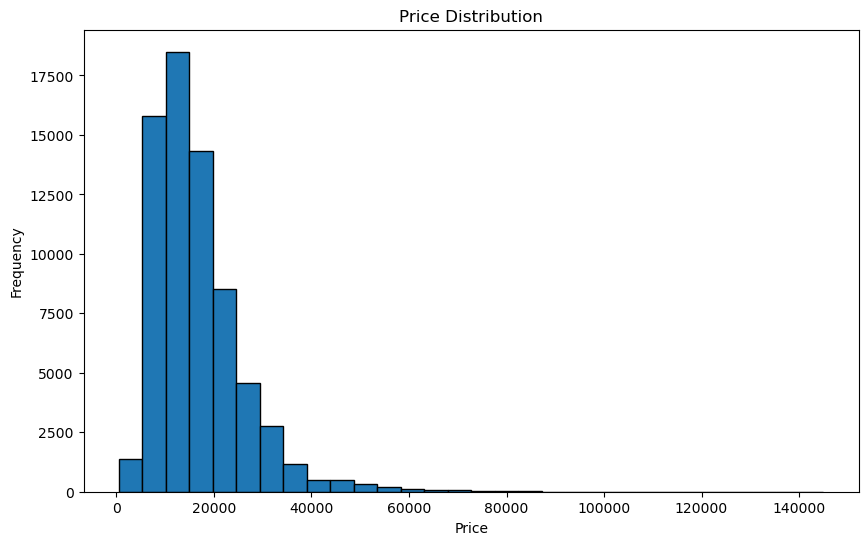

In [167]:
plt.figure(figsize=(10,6))
plt.hist(df['price'], bins=30, edgecolor='black')
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

### Features Related to Price
Correlation analysis was performed to determine which features are most related to price.

The features most positively related to price are (price , engineSize , year, tax).
The features least related to price are (mg , mileage).

This helps understand which factors influence car pricing.

In [168]:
correlation = df.corr(numeric_only=True)
print(correlation['price'].sort_values(ascending=False))

price         1.000000
engineSize    0.629839
year          0.519383
tax           0.353204
mpg          -0.335615
mileage      -0.427524
Name: price, dtype: float64


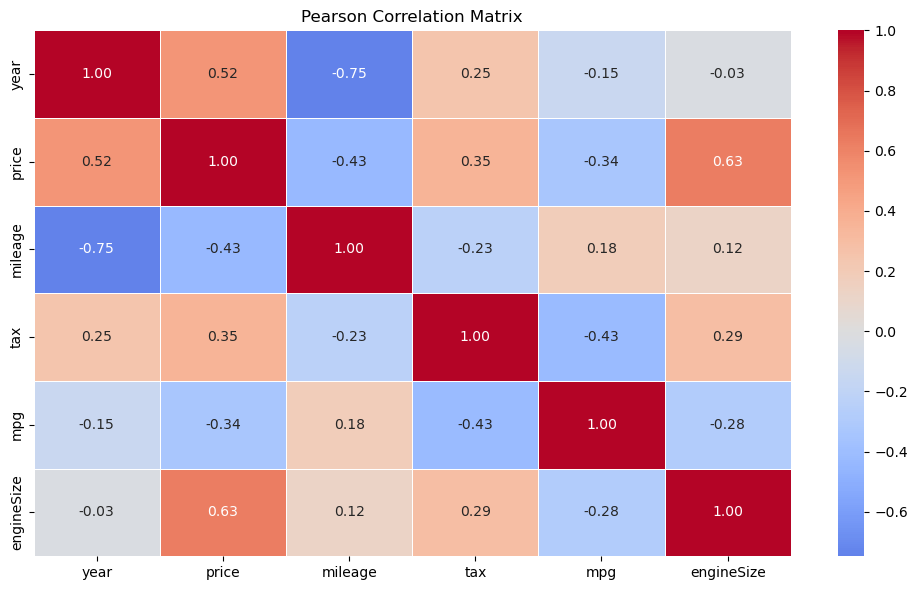

In [169]:
import seaborn as sns
# Select only numerical columns
corr = df.select_dtypes(include=[np.number]).corr()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.4)

plt.title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()

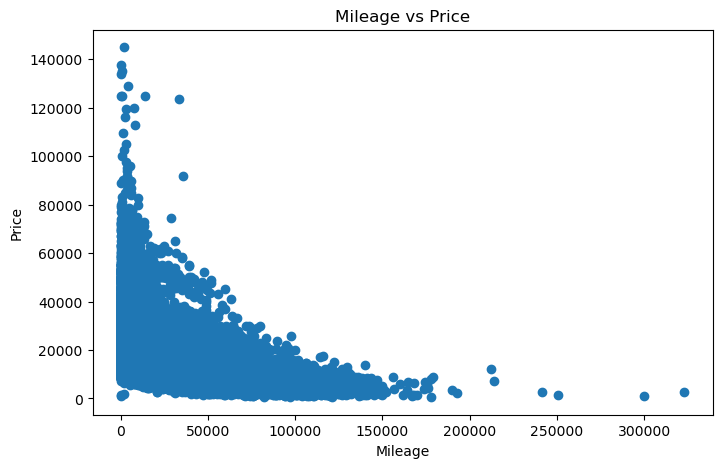

In [170]:
plt.figure(figsize=(8,5))
plt.scatter(df['mileage'], df['price'])
plt.title("Mileage vs Price")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.show()

This scatter plot shows the relationship between mileage and car price. Each point represents a car, where the x-axis shows mileage and the y-axis shows price.
The plot helps identify whether higher mileage is associated with lower car prices. Typically, cars with higher mileage tend to have lower prices, indicating a negative relationship between mileage and price.

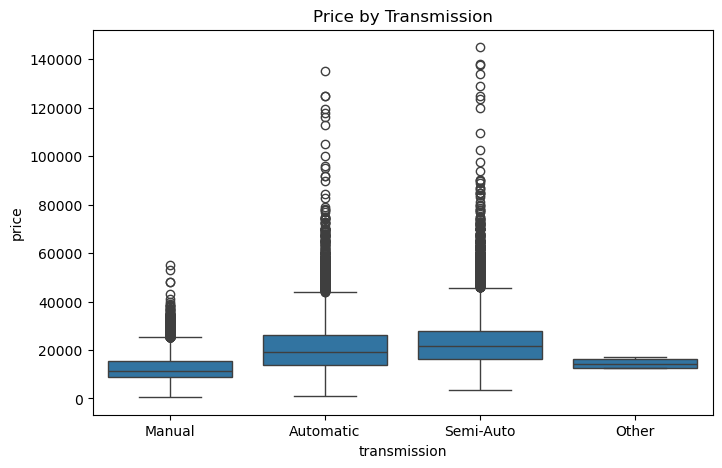

In [171]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['transmission'], y=df['price'])
plt.title("Price by Transmission")
plt.show()

The boxplot shows the distribution of price across different transmission types: Manual, Automatic, Semi-Auto, and Other. It can be observed that cars with Semi-Auto transmission have the highest median price, followed by Automatic cars.
Manual cars have the lowest median price and a smaller price range compared to the other categories. The Other category also has relatively lower prices with less variability.
Additionally, Semi-Auto and Automatic categories contain many high-price outliers, with prices exceeding 120,000, while Manual cars rarely reach such high values.
This suggests that transmission type has a significant impact on car pricing, with more advanced transmission systems generally associated with higher prices.

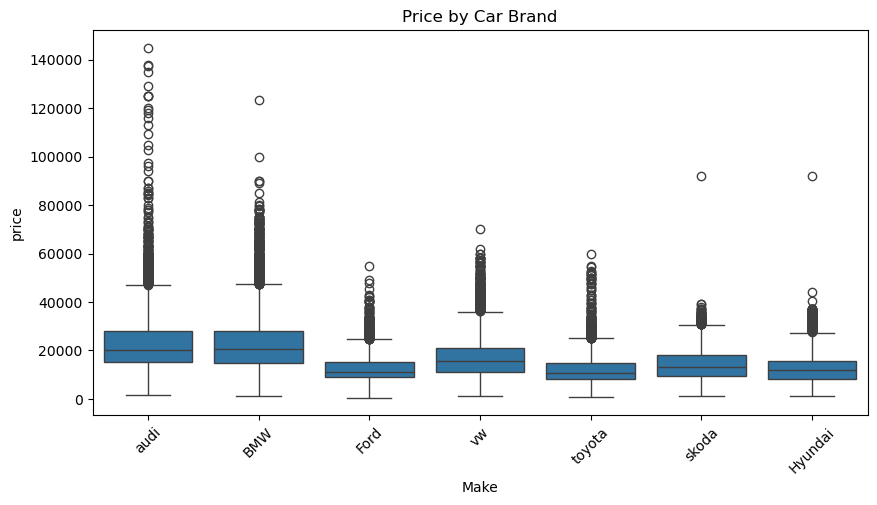

In [172]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['Make'], y=df['price'])
plt.xticks(rotation=45)
plt.title("Price by Car Brand")
plt.show()

The boxplot illustrates how price varies across different car brands including Audi, BMW, Ford, VW, Toyota, Skoda, and Hyundai. It is evident that Audi and BMW have the highest price ranges, with many cars exceeding 100,000, indicating that they are premium brands.
Volkswagen (VW) shows moderate pricing, with a higher median compared to brands like Ford, Toyota, and Hyundai.
Ford, Toyota, Skoda, and Hyundai generally have lower median prices, indicating that they are more affordable brands. However, some of these brands still show variability with a few higher-priced outliers.
Overall, the plot confirms that brand plays an important role in determining car price

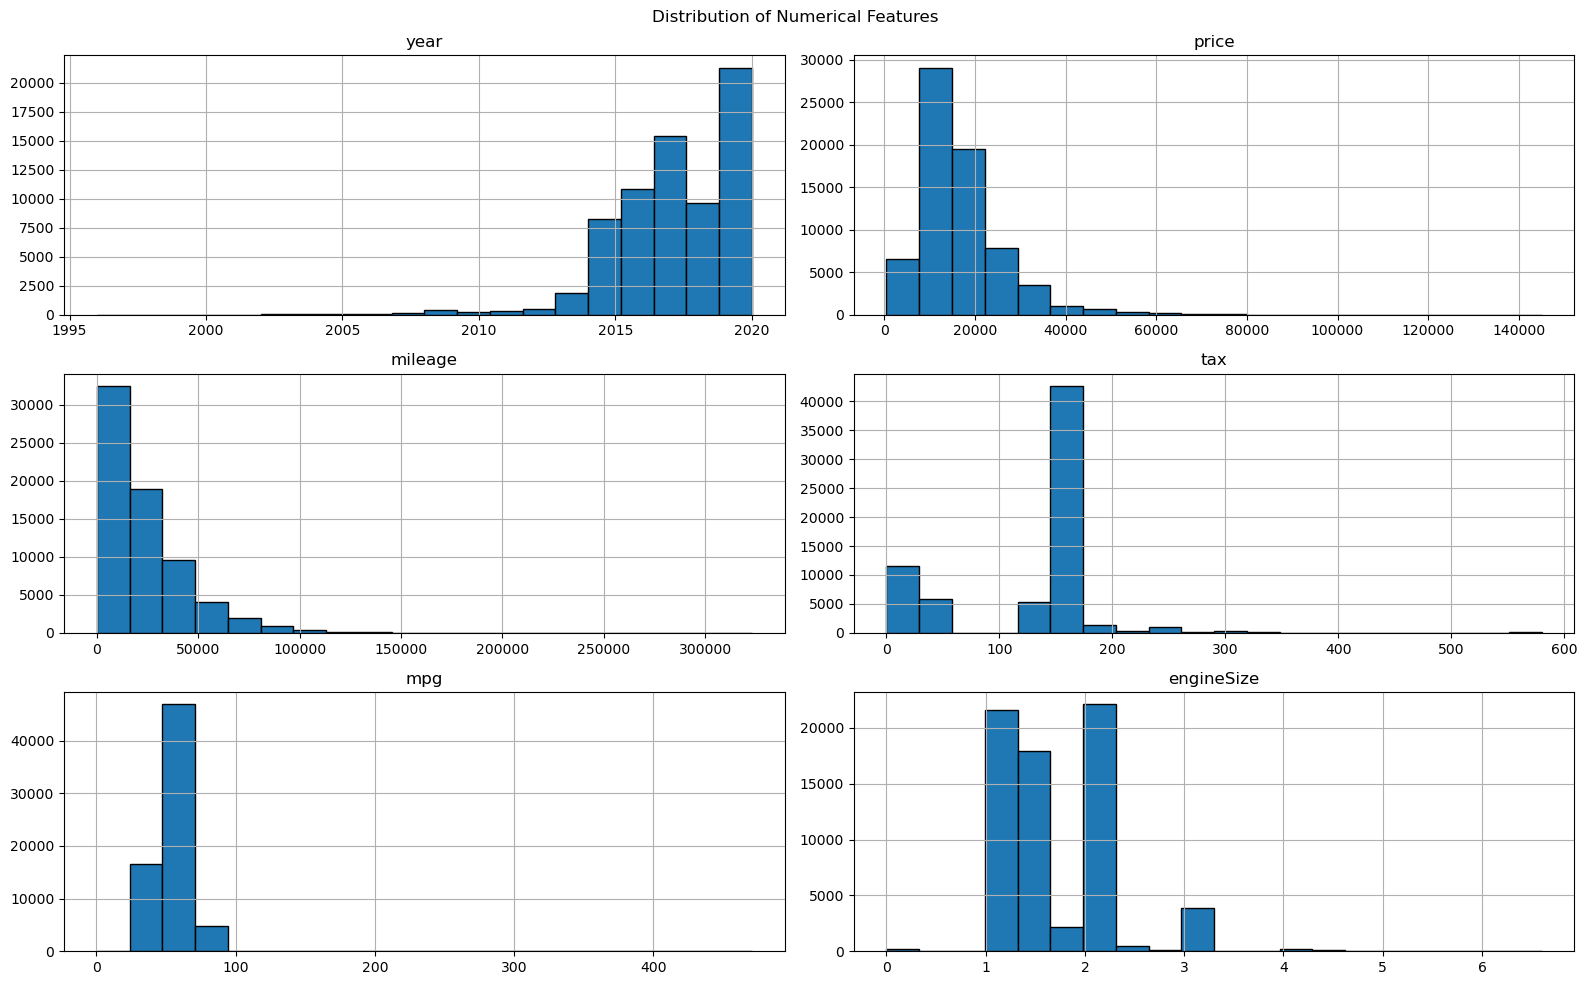

In [173]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
df[num_cols].hist(figsize=(16,10), bins=20, edgecolor='black')
plt.suptitle('Distribution of Numerical Features')
plt.tight_layout()
plt.show()

The histograms show the distribution of numerical features such as price, mileage, and engine size. Some features appear to be right-skewed, indicating that most values are concentrated at lower ranges with a few high-value outliers.

# Data Preprocessing for Car Price Dataset
## Handle Missing Values
We fill missing values with mean (numerical) and mode (categorical) to avoid losing data.

In [4]:
df = df.dropna(subset=['price'])
# 1. Split data


train, test = train_test_split(df, test_size=0.2, random_state=1)


# 2. Separate numerical & categorical
y_train = train['price']
y_test = test['price']

train = train.drop('price', axis=1) 
test = test.drop('price', axis=1)
num_cols = train.select_dtypes(include=np.number).columns.tolist()
cat_cols = train.select_dtypes(include=['string','object']).columns.tolist()



# 3. Impute Numerical (mean)


num_imputer = SimpleImputer(strategy='mean')

train[num_cols] = num_imputer.fit_transform(train[num_cols])
test[num_cols] = num_imputer.transform(test[num_cols])



# 4. Impute Categorical (mode)


cat_imputer = SimpleImputer(strategy='most_frequent')
train[cat_cols] = cat_imputer.fit_transform(train[cat_cols])
test[cat_cols] = cat_imputer.transform(test[cat_cols])


## Encode Categorical Variables
We use One-Hot Encoding because categories have no order.

In [5]:
train = pd.get_dummies(train, columns=cat_cols, drop_first=True)
test = pd.get_dummies(test, columns=cat_cols, drop_first=True)

train, test = train.align(test, join='left', axis=1, fill_value=0)




## Feature Scaling
We use StandardScaler to normalize numerical features.

In [6]:
# 8. Scaling
X_train_unscaled = train.copy()
X_test_unscaled = test.copy()

scaler = StandardScaler()

train[num_cols] = scaler.fit_transform(train[num_cols])
test[num_cols] = scaler.transform(test[num_cols])
train

,year,mileage,tax,mpg,engineSize,model_ 2 Series,model_ 3 Series,model_ 4 Series,model_ 5 Series,model_ 6 Series,...,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
70471,-0.036480,-0.221475,0.448956,0.108054,-0.795925,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
58577,-0.036480,0.173226,-1.868901,0.776928,-1.163154,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
8373,-1.013883,0.674459,0.448956,-0.028088,0.672991,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
11672,-0.036480,0.869415,0.448956,-0.028088,0.672991,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
20801,-0.036480,0.262130,0.129252,-0.211585,-0.245082,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51690,1.429624,-0.873404,0.448956,-0.093200,-1.163154,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
21659,-1.502585,0.389210,-1.868901,0.581593,-1.163154,False,False,False,False,False,...,False,False,False,True,True,False,False,False,False,False
22549,0.940923,0.000000,0.528883,0.179085,-1.163154,False,False,False,False,False,...,False,False,False,True,True,False,False,False,False,False
52695,-0.036480,0.345477,0.448956,-0.152392,-0.795925,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True


## Handle Outliers (IQR Method)
We cap extreme values using the IQR method.

In [7]:
cols_to_cap = ['mileage', 'tax']

for col in cols_to_cap:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1

    train[col] = np.clip(train[col], Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
    test[col] = np.clip(test[col], Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)



In [8]:
X_train = train
X_test = test

## Threshold to categorize price

In [9]:
price_train=y_train
price_test=y_test
cheap=price_train.quantile(1/3)
expensive=price_train.quantile(2/3)
print(cheap)
print(expensive)

11490.0
17999.0


In [10]:
#crate category (y) colmn
def category(price):
    if price<= cheap:
        return "Cheap"
    elif price<= expensive and price>= cheap:
        return "Moderate"    
    else:
        return "Expensive" 
    
y_train_knn=price_train.apply(category)
y_train_knn.name='Price catergory'
y_test_knn=price_test.apply(category)
y_test_knn.name='Price catergory'    

In [11]:
#number of cars per each category
print(y_train_knn.value_counts())
print(y_test_knn.value_counts())
y_train_knn.shape

Price catergory
Cheap        18397
Moderate     18328
Expensive    18326
Name: count, dtype: int64
Price catergory
Moderate     4611
Expensive    4607
Cheap        4545
Name: count, dtype: int64


(55051,)

### Threshold justification
 - The price thresholds were determined using the 33rd and 66th percentiles of the car price distribution.
 - This creates three categories: Cheap, Moderate, and Expensive.
 - This ensures approximately equal class sizes (33%/33%/34%) to make balanced data and prevents class imbalance that could negatively impact KNN classification performance.
 - This histogram shows that the categories are almost equal. 

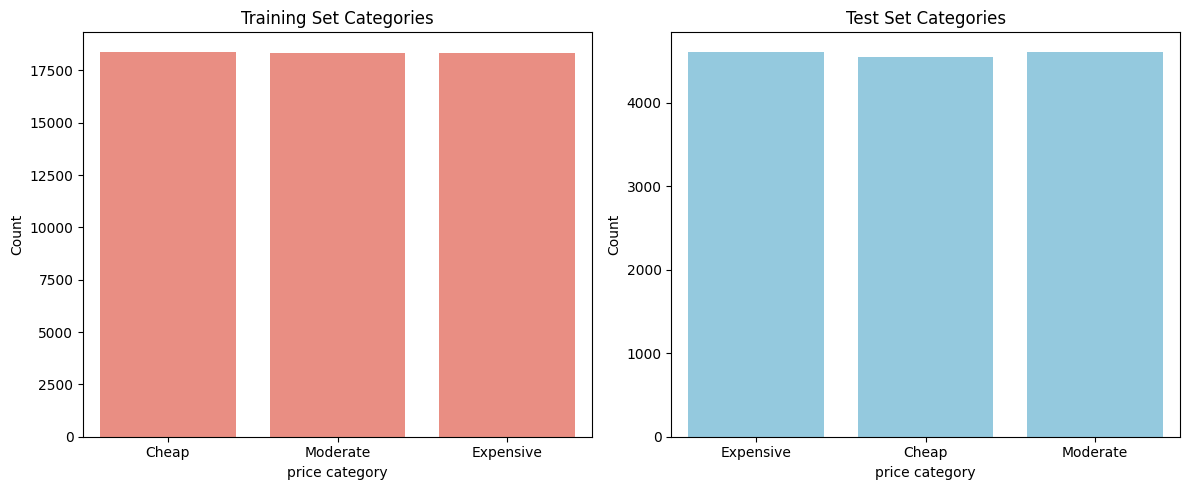

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training
sns.countplot(ax=axes[0], x=y_train_knn,color='salmon' )
axes[0].set_title('Training Set Categories')
axes[0].set_xlabel('price category')
axes[0].set_ylabel('Count')

# Test
sns.countplot(ax=axes[1], x=y_test_knn,color='skyblue' )
axes[1].set_title('Test Set Categories')
axes[1].set_xlabel('price category')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Regression
We will train a Linear Regression model to predict the exact car price using training data and evaluate it on unseen test data.

## Training Regression Model


In [13]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Prediction

In [184]:
y_pred = model.predict(X_test)

## Model Evaluation

In [185]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae=mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2303.446714587828
MSE: 12283239.764892494
RMSE: 3504.7453209744776
R2 Score: 0.856523789039079


## Visualization

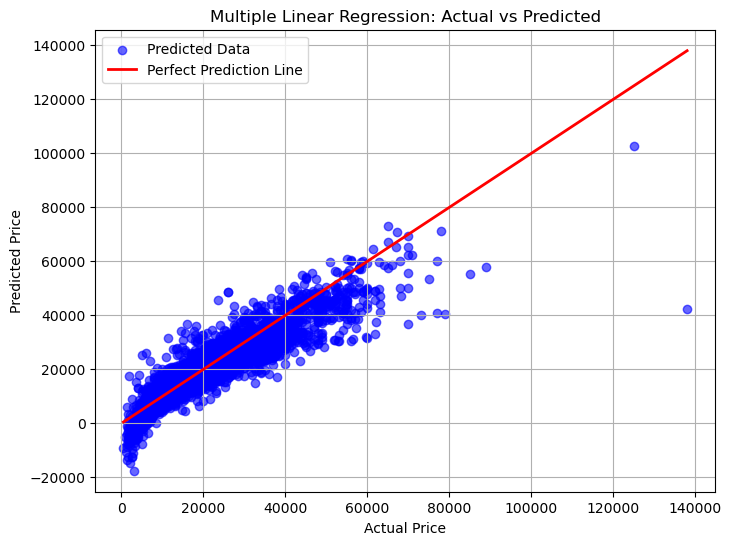

In [186]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, color='blue', alpha=0.6, label='Predicted Data')

plt.plot([y_test.min(), y_test.max()],
[y_test.min(), y_test.max()],
color='red', linewidth=2, label='Perfect Prediction Line')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Multiple Linear Regression: Actual vs Predicted")

plt.legend()
plt.grid(True)
plt.show()

# classification

#### define x for train/test

In [14]:
#no_features=['year','mileage','tax','mpg','engineSize','fuelType_Electric','fuelType_Hybrid','fuelType_Other','fuelType_Petrol',
#            'Make_Ford','Make_Hyundai','Make_audi','Make_skoda','Make_toyota','Make_vw']
# no_features=['year','mileage','tax','mpg','engineSize']
x_train_knn=train
x_test_knn=test
x_train_knn

,year,mileage,tax,mpg,engineSize,model_ 2 Series,model_ 3 Series,model_ 4 Series,model_ 5 Series,model_ 6 Series,...,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_Ford,Make_Hyundai,Make_audi,Make_skoda,Make_toyota,Make_vw
70471,-0.036480,-0.221475,0.448956,0.108054,-0.795925,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
58577,-0.036480,0.173226,-0.673435,0.776928,-1.163154,False,False,False,False,False,...,False,False,False,True,False,False,False,False,True,False
8373,-1.013883,0.674459,0.448956,-0.028088,0.672991,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
11672,-0.036480,0.869415,0.448956,-0.028088,0.672991,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
20801,-0.036480,0.262130,0.129252,-0.211585,-0.245082,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51690,1.429624,-0.873404,0.448956,-0.093200,-1.163154,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
21659,-1.502585,0.389210,-0.673435,0.581593,-1.163154,False,False,False,False,False,...,False,False,False,True,True,False,False,False,False,False
22549,0.940923,0.000000,0.528883,0.179085,-1.163154,False,False,False,False,False,...,False,False,False,True,True,False,False,False,False,False
52695,-0.036480,0.345477,0.448956,-0.152392,-0.795925,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True


#### Grid search to find the best k and distance metric

In [19]:
param_grid = {
    'n_neighbors': range(3, 34,2),  
    'metric': ['euclidean', 'manhattan']  
}

In [20]:
knn = KNeighborsClassifier()
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=kfold,
    scoring='accuracy',
    n_jobs=-1,
)

In [21]:
grid_search.fit(x_train_knn, y_train_knn)
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 11}


#### evalute best model

In [22]:
best_k = grid_search.best_params_['n_neighbors']
best_metric = grid_search.best_params_['metric']

In [23]:
knn_best_model = KNeighborsClassifier(n_neighbors=best_k,metric=best_metric)
knn_best_model.fit(x_train_knn,y_train_knn)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",11
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'manhattan'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [24]:
y_pred= knn_best_model.predict(x_test_knn)
class_names=knn_best_model.classes_
print(classification_report(y_test_knn,y_pred,target_names=class_names))

              precision    recall  f1-score   support

       Cheap       0.91      0.90      0.91      4545
   Expensive       0.91      0.91      0.91      4607
    Moderate       0.82      0.83      0.83      4611

    accuracy                           0.88     13763
   macro avg       0.88      0.88      0.88     13763
weighted avg       0.88      0.88      0.88     13763



#### confusion matrix

In [25]:
conf_matrix=confusion_matrix(y_test_knn,y_pred)
print(conf_matrix)

[[4105    4  436]
 [   2 4207  398]
 [ 383  397 3831]]


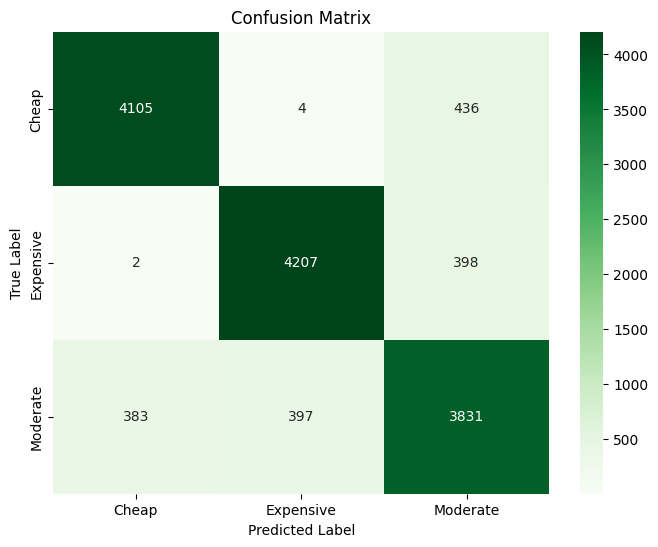

In [26]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens',xticklabels=class_names,yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Model Comparison
1-Linear Regression model performed better in predicting the actual car price value and the model achieving a high $R^2$ score around(0.857), this mean model explains about 85,65% of the variance in car prices.
Better in this context mean having a lowerr error(MSE/RMSE) and a higher $R^2$ score.
Classification model performed better in categorizing cars into price classes(Cheap,Moderate,Expensive) and the model achiving good performance with accuracy of 88%.
Better in this context mean correctly assigning class labels while maximizing performance metrics such as accuracy, precision and F1-score.

2-Classification is not significantly easier than regression, as both model achieved similar performance ($R^2$ $\approx$ 0.857 for regression and accuracy 0.88 for classification). However classification may appear easier because it simplifies the problem into discrete categories, making it more tolerant to noise and easier to learn.

3-converting price into categories lose important information. continuous price value show exact differences between prices, while categorization groups different values into the same class.

## Sensitivity Analysis
1-removing the most correlated feature "eigensize" will reduce model performance. The classification accuracy reduced from 0.85 to 0.82 and $R^2$ reduced from 0.8565 to 0.8332, we would see a slight to moderate drop in performance, but not a significant drop. 

2-Running KNN without scaling lead to reduce performance (accurcy reduced from 88% to 58%).

In [27]:
# 1. Load data
df_exp = pd.read_csv('car_price.csv')
df_exp = df_exp.dropna(subset=['price'])

# 2. Split
train_exp, test_exp = train_test_split(df_exp, test_size=0.2, random_state=1)

# 3. Separate target
y_train_exp = train_exp['price']
y_test_exp = test_exp['price']

train_exp = train_exp.drop('price', axis=1)
test_exp = test_exp.drop('price', axis=1)

# 4. Get column names
num_cols_exp = train_exp.select_dtypes(include=np.number).columns.tolist()
cat_cols_exp = train_exp.select_dtypes(include='object').columns.tolist()

# 5. Impute numerical (mean)
num_imputer = SimpleImputer(strategy='mean')
train_exp[num_cols_exp] = num_imputer.fit_transform(train_exp[num_cols_exp])
test_exp[num_cols_exp] = num_imputer.transform(test_exp[num_cols_exp])

# 6. Impute categorical (mode)
cat_imputer = SimpleImputer(strategy='most_frequent')
train_exp[cat_cols_exp] = cat_imputer.fit_transform(train_exp[cat_cols_exp])
test_exp[cat_cols_exp] = cat_imputer.transform(test_exp[cat_cols_exp])

# 7. Encode categorical
train_exp = pd.get_dummies(train_exp, columns=cat_cols_exp, drop_first=True)
test_exp = pd.get_dummies(test_exp, columns=cat_cols_exp, drop_first=True)
train_exp, test_exp = train_exp.align(test_exp, join='left', axis=1, fill_value=0)

# 9. Handle outliers (IQR)
cols_to_cap = ['mileage', 'tax']
for col in cols_to_cap:
    if col in train_exp.columns:
        Q1 = train_exp[col].quantile(0.25)
        Q3 = train_exp[col].quantile(0.75)
        IQR = Q3 - Q1
        train_exp[col] = np.clip(train_exp[col], Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
        test_exp[col] = np.clip(test_exp[col], Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

# 10. Create target categories
cheap_exp = y_train_exp.quantile(1/3)
expensive_exp = y_train_exp.quantile(2/3)

def category_exp(price):
    if price <= cheap_exp:
        return "Cheap"
    elif price <= expensive_exp:
        return "Moderate"
    else:
        return "Expensive"

y_train_knn_exp = y_train_exp.apply(category_exp)
y_test_knn_exp = y_test_exp.apply(category_exp)

 
# Reorder columns
x_train_exp = train_exp
x_test_exp = test_exp

# 12. Train KNN
knn_no_scale = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
knn_no_scale.fit(x_train_exp, y_train_knn_exp)
y_pred_no_scale = knn_no_scale.predict(x_test_exp)

# 13. Results
acc_no_scale = accuracy_score(y_test_knn_exp, y_pred_no_scale)
print(f" Classification Report (Without Scaling):")
print(classification_report(y_test_knn_exp, y_pred_no_scale, target_names=['Cheap', 'Moderate', 'Expensive']))

C:\Users\HP Zbook G5\AppData\Local\Temp\ipykernel_15860\4044272819.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_exp = train_exp.select_dtypes(include='object').columns.tolist()


 Classification Report (Without Scaling):
              precision    recall  f1-score   support

       Cheap       0.57      0.67      0.62      4545
    Moderate       0.71      0.72      0.72      4607
   Expensive       0.47      0.38      0.42      4611

    accuracy                           0.59     13763
   macro avg       0.58      0.59      0.59     13763
weighted avg       0.58      0.59      0.59     13763



3-changing threshold for price categories had a noticeable but limited impact on KNN accuracy. using threshold of 0.2 and 0.8 instead of cheap 1/3 and expensive 2/3 increased accuracy from 0.85 to 0.886 while other threshold such as 0.25, 0.75 slightly increasr from 0.85 to 0.865 and 0.30 ,0.70 achieve the same accuracy 0.85 to the first threshold , changes in threshold did not significantly affect performance.

In [28]:
thresholds_to_test = {
    '20/80': (0.20, 0.80),
    '25/75': (0.25, 0.75),
    '30/70': (0.30, 0.70),
}
for name, (q1, q2) in thresholds_to_test.items():
    # Calculate threshold values
    cheap_val = y_train.quantile(q1)
    expensive_val = y_train.quantile(q2)
    
    # Create category function
    def category_new(price):
        if pd.isna(price):
            return np.nan
        elif price <= cheap_val:
            return "Cheap"
        elif price <= expensive_val:
            return "Moderate"
        else:
            return "Expensive"
    # Apply new categories
    y_train_new = y_train.apply(category_new)
    y_test_new = y_test.apply(category_new)
    
    # Train KNN with new categories
    knn_new = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
    knn_new.fit(x_train_knn, y_train_new)
    y_pred_new = knn_new.predict(x_test_knn)
    
    # Accuracy with new thresholds
    acc_new = accuracy_score(y_test_new, y_pred_new)
    
    # Class distribution
    class_dist = y_train_new.value_counts()
        # Apply new categories
    y_train_new = y_train.apply(category_new)
    y_test_new = y_test.apply(category_new)
    
    # Train KNN with new categories
    knn_new = KNeighborsClassifier(n_neighbors=best_k, metric=best_metric)
    knn_new.fit(x_train_knn, y_train_new)
    y_pred_new = knn_new.predict(x_test_knn)
    
    # Accuracy with new thresholds
    acc_new = accuracy_score(y_test_new, y_pred_new)
    
    # Class distribution
    class_dist = y_train_new.value_counts()

    print(f"\nThreshold: {name} ")
    print(f" Accuracy: {acc_new:.4f}")
    print(" Class Distribution in Training Set:")   
    print(class_dist)



Threshold: 20/80 
 Accuracy: 0.9042
 Class Distribution in Training Set:
price
Moderate     33079
Cheap        11036
Expensive    10936
Name: count, dtype: int64

Threshold: 25/75 
 Accuracy: 0.8872
 Class Distribution in Training Set:
price
Moderate     27523
Cheap        13765
Expensive    13763
Name: count, dtype: int64

Threshold: 30/70 
 Accuracy: 0.8835
 Class Distribution in Training Set:
price
Moderate     22044
Cheap        16629
Expensive    16378
Name: count, dtype: int64
